In [4]:
import random
import warnings
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Data Preparation
The cleaned dataset contains 1,111,082 valid games after removing rows with missing values in the required Elo, opening, and result fields. The target variable `ExpectedScore` was encoded as `0.0` for losses, `0.5` for draws, and `1.0` for wins.

The class balance shows that wins and losses are nearly even, while draws are much less frequent. This means the model is learning from a mostly balanced outcome distribution, but draw prediction may still be harder because draws are relatively rare.


In [5]:
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
N_FOLDS_OOF = 5
ALPHA_GRID = [5, 10, 20, 50]
N_TRIALS = 12
MAX_BOOST_ROUNDS = 2000
EARLY_STOPPING_ROUNDS = 100

random.seed(SEED)
np.random.seed(SEED)

print("Config loaded:")
print({
    "SEED": SEED,
    "splits": (TRAIN_SIZE, VAL_SIZE, TEST_SIZE),
    "N_FOLDS_OOF": N_FOLDS_OOF,
    "ALPHA_GRID": ALPHA_GRID,
    "N_TRIALS": N_TRIALS,
})

Config loaded:
{'SEED': 42, 'splits': (0.7, 0.15, 0.15), 'N_FOLDS_OOF': 5, 'ALPHA_GRID': [5, 10, 20, 50], 'N_TRIALS': 12}


### Train/Validation/Test Split
The dataset was split into 70% training, 15% validation, and 15% test sets using stratification on the target outcome. This preserves the original class proportions across all splits and makes the validation and test results more reliable.

This setup allows the model to be trained on a large sample while still reserving enough unseen data for model selection and final evaluation.


In [6]:
# -----------------------------
# Helper functions
# -----------------------------

def map_expected_score(result_series: pd.Series) -> pd.Series:
    s = result_series.copy()

    if pd.api.types.is_numeric_dtype(s):
        out = pd.to_numeric(s, errors="coerce")
        out = out.where(out.isin([0.0, 0.5, 1.0]))
        return out

    s = s.astype(str).str.strip()
    mapping = {
        "1-0": 1.0,
        "0-1": 0.0,
        "1/2-1/2": 0.5,
        "0.5-0.5": 0.5,
        "1": 1.0,
        "0": 0.0,
        "0.5": 0.5,
    }
    return s.map(mapping)


def make_stratify_labels(y_expected: pd.Series) -> pd.Series:
    return y_expected.map({0.0: "loss", 0.5: "draw", 1.0: "win"})


def add_opening_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    df_out["Opening"] = df_out["Opening"].fillna("Unknown").astype(str)

    bins = [0, 1200, 1400, 1600, 1800, 2000, 2200, 4000]
    labels = ["under_1200", "1200_1399", "1400_1599", "1600_1799", "1800_1999", "2000_2199", "over_2200"]
    df_out["Elo_Bracket"] = pd.cut(df_out["Avg_Elo"], bins=bins, labels=labels, include_lowest=True)
    df_out["Elo_Bracket"] = df_out["Elo_Bracket"].astype(str)

    return df_out


def smoothed_target_map(cat_series: pd.Series, y: pd.Series, alpha: float):
    tmp = pd.DataFrame({"cat": cat_series, "y": y})
    global_mean = tmp["y"].mean()
    stats = tmp.groupby("cat")["y"].agg(["count", "mean"])
    smooth = (stats["count"] * stats["mean"] + alpha * global_mean) / (stats["count"] + alpha)
    return smooth.to_dict(), float(global_mean)


def add_oof_target_encoding(train_df, val_df, test_df, cat_col, target_col, alpha, n_folds=5, seed=42):
    train_enc = pd.Series(index=train_df.index, dtype=float)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    strat_labels = make_stratify_labels(train_df[target_col])

    for tr_idx, oof_idx in skf.split(train_df, strat_labels):
        tr_part = train_df.iloc[tr_idx]
        oof_part = train_df.iloc[oof_idx]

        mapping, gm = smoothed_target_map(tr_part[cat_col], tr_part[target_col], alpha)
        train_enc.iloc[oof_idx] = oof_part[cat_col].map(mapping).fillna(gm)

    full_mapping, full_gm = smoothed_target_map(train_df[cat_col], train_df[target_col], alpha)
    val_enc = val_df[cat_col].map(full_mapping).fillna(full_gm)
    test_enc = test_df[cat_col].map(full_mapping).fillna(full_gm)

    return train_enc, val_enc, test_enc


def make_model_matrices(train_df, val_df, test_df, alpha, seed=42):
    tr_opening, va_opening, te_opening = add_oof_target_encoding(
        train_df, val_df, test_df, "Opening", "ExpectedScore", alpha, n_folds=N_FOLDS_OOF, seed=seed
    )

    train_x = train_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()
    val_x = val_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()
    test_x = test_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()

    train_x["Opening_TE"] = tr_opening
    val_x["Opening_TE"] = va_opening
    test_x["Opening_TE"] = te_opening

    train_x["Opening_TE_x_ELODIFF"] = train_x["Opening_TE"] * train_x["Elo_Diff"]
    val_x["Opening_TE_x_ELODIFF"] = val_x["Opening_TE"] * val_x["Elo_Diff"]
    test_x["Opening_TE_x_ELODIFF"] = test_x["Opening_TE"] * test_x["Elo_Diff"]

    all_brackets = pd.concat([train_df["Elo_Bracket"], val_df["Elo_Bracket"], test_df["Elo_Bracket"]], axis=0, ignore_index=True)
    bracket_dummies = pd.get_dummies(all_brackets, prefix="ELO_B", dtype=int)

    bracket_train = bracket_dummies.iloc[:len(train_df)]
    bracket_val = bracket_dummies.iloc[len(train_df):len(train_df)+len(val_df)]
    bracket_test = bracket_dummies.iloc[len(train_df)+len(val_df):]

    bracket_train.index = train_df.index
    bracket_val.index = val_df.index
    bracket_test.index = test_df.index

    train_x = pd.concat([train_x, bracket_train], axis=1)
    val_x = pd.concat([val_x, bracket_val], axis=1)
    test_x = pd.concat([test_x, bracket_test], axis=1)

    assert train_x.isnull().sum().sum() == 0, "NaNs in train features"
    assert val_x.isnull().sum().sum() == 0, "NaNs in val features"
    assert test_x.isnull().sum().sum() == 0, "NaNs in test features"

    return train_x, val_x, test_x


def calibration_table(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    df_cal = pd.DataFrame({"y": y_true, "p": y_pred})
    df_cal["bin"] = pd.cut(df_cal["p"], bins=bins, include_lowest=True)

    tab = df_cal.groupby("bin", observed=True).agg(
        pred_mean=("p", "mean"),
        obs_mean=("y", "mean"),
        n=("y", "size"),
    ).reset_index()

    tab = tab[tab["n"] > 0].copy()
    tab["abs_gap"] = (tab["pred_mean"] - tab["obs_mean"]).abs()
    ece = float((tab["abs_gap"] * tab["n"]).sum() / tab["n"].sum())
    return tab, ece


def eval_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": rmse, "mae": float(mae), "mse_brier": float(mse)}


In [7]:
from pathlib import Path

balanced_base = Path(r"/Users/phamhoanghai/Ureca/dataset/final_data_by_event_group/top30_balanced")
EVENT_FILES = {
    "rated_bullet": balanced_base / "rated_bullet_top30_balanced.csv",
    "rated_blitz": balanced_base / "rated_blitz_top30_balanced.csv",
    "rated_classical": balanced_base / "rated_classical_top30_balanced.csv",
    "rated_correspondence": balanced_base / "rated_correspondence_top30_balanced.csv",
}
EVENT_ORDER = list(EVENT_FILES.keys())

missing_files = [str(path) for path in EVENT_FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing balanced dataset files: {missing_files}")

splits_by_event = {}
dataset_summary = []

for event_name, file_path in EVENT_FILES.items():
    event_df = pd.read_csv(file_path)

    if "Opening" not in event_df.columns:
        raise ValueError(f"{event_name} is missing the 'Opening' column.")

    event_df["Opening"] = event_df["Opening"].fillna("Unknown").astype(str)
    event_df = event_df.rename(
        columns={
            "WhiteEloNumeric": "WhiteElo",
            "BlackEloNumeric": "BlackElo",
            "EloDiff": "Elo_Diff",
            "AvgElo": "Avg_Elo",
        }
    )

    required_cols = ["Opening", "WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo", "Result"]
    missing = [c for c in required_cols if c not in event_df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {event_name}: {missing}")

    pipeline_df = event_df[required_cols].copy()
    pipeline_df["ExpectedScore"] = map_expected_score(pipeline_df["Result"])
    pipeline_df = pipeline_df.dropna(
        subset=["ExpectedScore", "WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo", "Opening"]
    ).copy()
    pipeline_df = pipeline_df[pipeline_df["ExpectedScore"].isin([0.0, 0.5, 1.0])].copy()
    pipeline_df = add_opening_features(pipeline_df)

    strat_all = make_stratify_labels(pipeline_df["ExpectedScore"])
    train_df, temp_df = train_test_split(
        pipeline_df,
        test_size=(VAL_SIZE + TEST_SIZE),
        random_state=SEED,
        stratify=strat_all,
    )

    temp_strat = make_stratify_labels(temp_df["ExpectedScore"])
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=SEED,
        stratify=temp_strat,
    )

    splits_by_event[event_name] = {
        "pipeline_df": pipeline_df,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
    }
    dataset_summary.append({
        "event": event_name,
        "rows": len(pipeline_df),
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_rows": len(test_df),
        "openings": pipeline_df["Opening"].nunique(),
    })

summary_df = pd.DataFrame(dataset_summary).sort_values("event").reset_index(drop=True)
display(summary_df)


,event,rows,train_rows,val_rows,test_rows,openings
0,rated_blitz,85530,59871,12829,12830,30
1,rated_bullet,49830,34881,7474,7475,30
2,rated_classical,64620,45234,9693,9693,30
3,rated_correspondence,690,483,103,104,30


In [8]:
@dataclass
class TuneResult:
    alpha: float
    params: dict
    best_iteration: int
    val_metrics: dict
    val_ece: float
    model: object


def random_params(rng):
    return {
        "objective": "reg:logistic",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "seed": SEED,
        "eta": float(rng.choice([0.02, 0.03, 0.05, 0.08, 0.1])),
        "max_depth": int(rng.choice([3, 4, 5, 6, 7])),
        "min_child_weight": float(rng.choice([1, 2, 4, 6, 8])),
        "gamma": float(rng.choice([0.0, 0.1, 0.3, 0.5, 1.0])),
        "subsample": float(rng.choice([0.7, 0.8, 0.9, 1.0])),
        "colsample_bytree": float(rng.choice([0.6, 0.7, 0.8, 0.9, 1.0])),
        "reg_lambda": float(rng.choice([0.5, 1.0, 2.0, 5.0, 10.0])),
    }


best_by_event = {}
tuning_summary = []

for event_name, split_data in splits_by_event.items():
    rng = np.random.default_rng(SEED)
    train_df = split_data["train_df"]
    val_df = split_data["val_df"]
    test_df = split_data["test_df"]

    best = None

    for alpha in ALPHA_GRID:
        X_train, X_val, _ = make_model_matrices(train_df, val_df, test_df, alpha=alpha, seed=SEED)

        y_train = train_df["ExpectedScore"].values
        y_val = val_df["ExpectedScore"].values

        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)

        for _ in range(N_TRIALS):
            params = random_params(rng)

            model = xgb.train(
                params=params,
                dtrain=dtrain,
                num_boost_round=MAX_BOOST_ROUNDS,
                evals=[(dtrain, "train"), (dval, "val")],
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                verbose_eval=False,
            )

            val_pred = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
            val_pred = np.clip(val_pred, 0.0, 1.0)

            val_metrics = eval_metrics(y_val, val_pred)
            _, val_ece = calibration_table(y_val, val_pred, n_bins=10)

            result = TuneResult(
                alpha=alpha,
                params=params,
                best_iteration=int(model.best_iteration),
                val_metrics=val_metrics,
                val_ece=val_ece,
                model=model,
            )

            if best is None:
                best = result
            else:
                b_rmse = best.val_metrics["rmse"]
                r_rmse = result.val_metrics["rmse"]
                if (r_rmse < b_rmse) or (np.isclose(r_rmse, b_rmse) and result.val_ece < best.val_ece):
                    best = result

    best_by_event[event_name] = best
    tuning_summary.append({
        "event": event_name,
        "best_alpha": best.alpha,
        "best_iteration": best.best_iteration,
        "val_rmse": best.val_metrics["rmse"],
        "val_mae": best.val_metrics["mae"],
        "val_ece": best.val_ece,
    })

print("Tuning complete for all events.")
display(pd.DataFrame(tuning_summary).sort_values("event").reset_index(drop=True))


Tuning complete for all events.


,event,best_alpha,best_iteration,val_rmse,val_mae,val_ece
0,rated_blitz,20,79,0.453855,0.416063,0.004008
1,rated_bullet,5,88,0.450342,0.410194,0.016966
2,rated_classical,5,227,0.457790,0.423734,0.008867
3,rated_correspondence,10,145,0.425236,0.392584,0.097347


### Hyperparameter Tuning
A random search was performed across 48 trials using different XGBoost hyperparameter combinations and target-encoding smoothing values (`alpha`). The best configuration achieved the lowest validation RMSE while also maintaining good calibration.

The selected smoothing parameter was `alpha = 50`, suggesting that moderate smoothing gave the best balance between learning opening-specific patterns and avoiding overfitting to rare openings.


In [41]:
from pathlib import Path
import json
import joblib

base_save_dir = Path(r"/Users/phamhoanghai/Ureca/Question_one/saved_state_top30_balanced")
base_save_dir.mkdir(parents=True, exist_ok=True)

results_to_save = globals().get("trained_results_by_event")
if results_to_save is None:
    results_to_save = globals().get("restored_results_by_event")

if results_to_save is None:
    existing_save_dirs = [event_name for event_name in EVENT_ORDER if (base_save_dir / event_name / "best_model.json").exists()]
    if existing_save_dirs:
        print(
            "No in-memory event results found. Saved model files already exist for:",
            existing_save_dirs,
        )
        print("Run the restore-from-disk cell if you want to load them into this session.")
    else:
        print("No trained event results are available yet. Run the all-events training cell first.")
    results_to_save = {}

if results_to_save:
    for event_name in EVENT_ORDER:
        result = results_to_save[event_name]
        save_dir = base_save_dir / event_name
        save_dir.mkdir(parents=True, exist_ok=True)

        joblib.dump(result["train_df"], save_dir / "train_df.joblib")
        joblib.dump(result["val_df"], save_dir / "val_df.joblib")
        joblib.dump(result["test_df"], save_dir / "test_df.joblib")

        best = result["best"]
        best_state = {
            "event": event_name,
            "alpha": best.alpha,
            "params": best.params,
            "best_iteration": best.best_iteration,
            "val_metrics": best.val_metrics,
            "val_ece": best.val_ece,
            "SEED": SEED,
        }
        with open(save_dir / "best_state.json", "w", encoding="utf-8") as f:
            json.dump(best_state, f, indent=2)

        result["final_model"].save_model(save_dir / "best_model.json")

    print(f"Saved state for all events under: {base_save_dir}")


Saved state for all events under: /Users/phamhoanghai/Ureca/Question_one/saved_state_top30_balanced


In [42]:
from pathlib import Path
import json
import joblib
import xgboost as xgb
from dataclasses import dataclass

base_save_dir = Path(r"/Users/phamhoanghai/Ureca/Question_one/saved_state_top30_balanced")
restored_results_by_event = {}

for event_name in EVENT_ORDER:
    save_dir = base_save_dir / event_name

    train_df = joblib.load(save_dir / "train_df.joblib")
    val_df = joblib.load(save_dir / "val_df.joblib")
    test_df = joblib.load(save_dir / "test_df.joblib")

    with open(save_dir / "best_state.json", "r", encoding="utf-8") as f:
        best_state = json.load(f)

    model = xgb.Booster()
    model.load_model(save_dir / "best_model.json")

    @dataclass
    class TuneResult:
        alpha: float
        params: dict
        best_iteration: int
        val_metrics: dict
        val_ece: float
        model: object

    best = TuneResult(
        alpha=best_state["alpha"],
        params=best_state["params"],
        best_iteration=best_state["best_iteration"],
        val_metrics=best_state["val_metrics"],
        val_ece=best_state["val_ece"],
        model=model,
    )

    restored_results_by_event[event_name] = {
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "best": best,
        "final_model": model,
    }

SEED = best_state["SEED"]
trained_results_by_event = restored_results_by_event
print(f"State restored for events: {list(restored_results_by_event.keys())}")


State restored for events: ['rated_bullet', 'rated_blitz', 'rated_classical', 'rated_correspondence']


In [43]:
trained_results_by_event = {}
train_eval_summary = []

for event_name in EVENT_ORDER:
    train_df = splits_by_event[event_name]["train_df"].copy()
    val_df = splits_by_event[event_name]["val_df"].copy()
    test_df = splits_by_event[event_name]["test_df"].copy()
    best = best_by_event[event_name]

    X_train_b, X_val_b, X_test_b = make_model_matrices(
        train_df, val_df, test_df, alpha=best.alpha, seed=SEED
    )

    y_train = train_df["ExpectedScore"].values
    y_val = val_df["ExpectedScore"].values

    dtrain_b = xgb.DMatrix(X_train_b, label=y_train)
    dval_b = xgb.DMatrix(X_val_b, label=y_val)

    best_model = xgb.train(
        params=best.params,
        dtrain=dtrain_b,
        num_boost_round=best.best_iteration + 1,
        evals=[(dtrain_b, "train"), (dval_b, "val")],
        verbose_eval=False,
    )

    val_pred = best_model.predict(dval_b, iteration_range=(0, best.best_iteration + 1))
    val_pred = np.clip(val_pred, 0.0, 1.0)
    val_metrics = eval_metrics(y_val, val_pred)
    val_cal, val_ece = calibration_table(y_val, val_pred, n_bins=10)

    trainval_df = pd.concat([train_df, val_df], axis=0).copy()
    X_trainval, _, X_test_final = make_model_matrices(
        trainval_df,
        val_df,
        test_df,
        alpha=best.alpha,
        seed=SEED,
    )

    y_trainval = trainval_df["ExpectedScore"].values
    y_test = test_df["ExpectedScore"].values

    dtrainval = xgb.DMatrix(X_trainval, label=y_trainval)
    dtest = xgb.DMatrix(X_test_final, label=y_test)

    final_model = xgb.train(
        params=best.params,
        dtrain=dtrainval,
        num_boost_round=best.best_iteration + 1,
        evals=[(dtrainval, "trainval")],
        verbose_eval=False,
    )

    test_pred = final_model.predict(dtest)
    test_pred = np.clip(test_pred, 0.0, 1.0)
    test_metrics = eval_metrics(y_test, test_pred)
    test_cal, test_ece = calibration_table(y_test, test_pred, n_bins=10)

    trained_results_by_event[event_name] = {
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "best": best,
        "best_model": best_model,
        "final_model": final_model,
        "val_metrics": val_metrics,
        "val_cal": val_cal,
        "val_ece": val_ece,
        "test_metrics": test_metrics,
        "test_cal": test_cal,
        "test_ece": test_ece,
        "test_pred": test_pred,
    }

    train_eval_summary.append({
        "event": event_name,
        "best_alpha": best.alpha,
        "best_iteration": best.best_iteration,
        "val_rmse": val_metrics["rmse"],
        "val_mae": val_metrics["mae"],
        "val_ece": val_ece,
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_ece": test_ece,
    })

train_eval_summary_df = pd.DataFrame(train_eval_summary).sort_values("event").reset_index(drop=True)
display(train_eval_summary_df)


,event,best_alpha,best_iteration,val_rmse,val_mae,val_ece,test_rmse,test_mae,test_ece
0,rated_blitz,20,79,0.453855,0.416063,0.004008,0.454306,0.416502,0.012809
1,rated_bullet,5,88,0.450342,0.410194,0.016966,0.448689,0.409661,0.012194
2,rated_classical,5,227,0.457790,0.423734,0.008867,0.459578,0.425454,0.013366
3,rated_correspondence,10,145,0.425236,0.392584,0.097347,0.457726,0.415394,0.073528


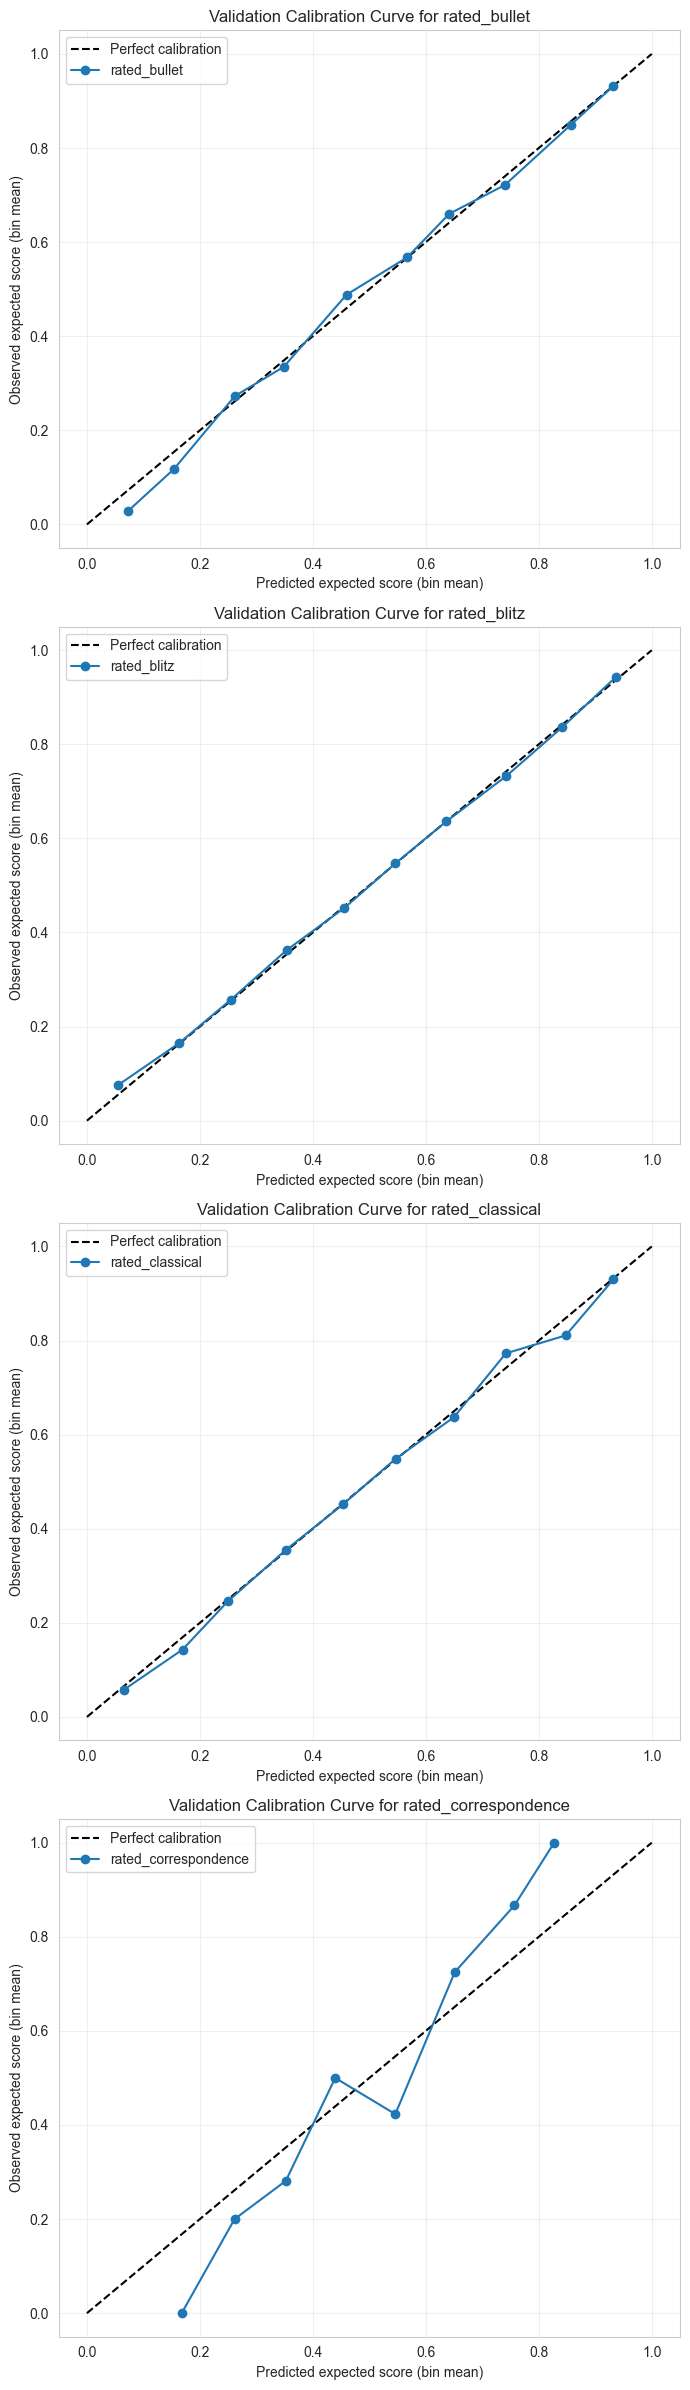

,event,val_rmse,val_mae,val_ece
0,rated_blitz,0.453855,0.416063,0.004008
1,rated_bullet,0.450342,0.410194,0.016966
2,rated_classical,0.457790,0.423734,0.008867
3,rated_correspondence,0.425236,0.392584,0.097347


In [44]:
fig, axes = plt.subplots(len(EVENT_ORDER), 1, figsize=(7, 6 * len(EVENT_ORDER)))
if len(EVENT_ORDER) == 1:
    axes = [axes]

for ax, event_name in zip(axes, EVENT_ORDER):
    val_cal = trained_results_by_event[event_name]["val_cal"]
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(val_cal["pred_mean"], val_cal["obs_mean"], marker="o", label=event_name)
    ax.set_xlabel("Predicted expected score (bin mean)")
    ax.set_ylabel("Observed expected score (bin mean)")
    ax.set_title(f"Validation Calibration Curve for {event_name}")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

display(train_eval_summary_df[["event", "val_rmse", "val_mae", "val_ece"]])


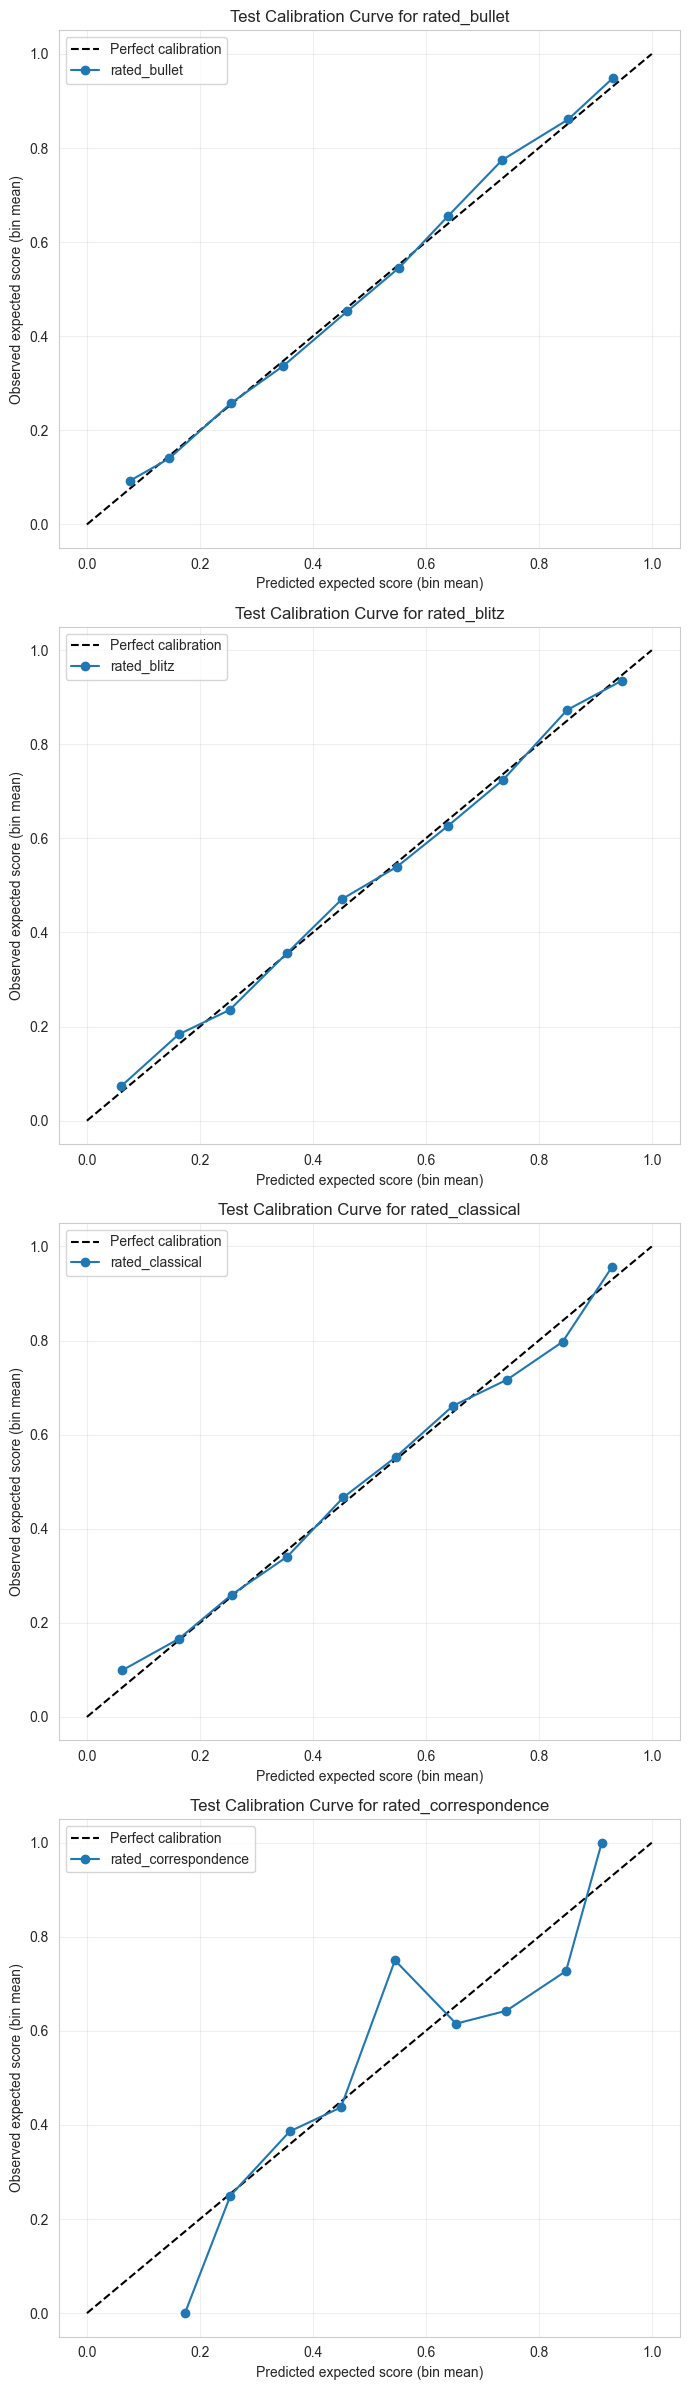

,event,test_rmse,test_mae,test_ece
0,rated_blitz,0.454306,0.416502,0.012809
1,rated_bullet,0.448689,0.409661,0.012194
2,rated_classical,0.459578,0.425454,0.013366
3,rated_correspondence,0.457726,0.415394,0.073528


In [45]:
fig, axes = plt.subplots(len(EVENT_ORDER), 1, figsize=(7, 6 * len(EVENT_ORDER)))
if len(EVENT_ORDER) == 1:
    axes = [axes]

for ax, event_name in zip(axes, EVENT_ORDER):
    test_cal = trained_results_by_event[event_name]["test_cal"]
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(test_cal["pred_mean"], test_cal["obs_mean"], marker="o", label=event_name)
    ax.set_xlabel("Predicted expected score (bin mean)")
    ax.set_ylabel("Observed expected score (bin mean)")
    ax.set_title(f"Test Calibration Curve for {event_name}")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

display(train_eval_summary_df[["event", "test_rmse", "test_mae", "test_ece"]])


### Best Model Result
The best model reached a validation RMSE of `0.4524`, MAE of `0.4132`, and MSE/Brier-style score of `0.2040`. These values indicate that the model has moderate predictive accuracy for expected score prediction.

Given that the target ranges from 0 to 1 and is influenced by many factors beyond opening and Elo, this is a reasonable result for exploratory analysis, though not strong enough for highly precise game-level prediction.


### Calibration Result
The validation Expected Calibration Error (ECE) was `0.0027`, which indicates excellent calibration. In other words, the model’s predicted expected scores are very close to the actual observed outcomes on average.

This is an important strength of the model because it means the predictions are not only ranked reasonably well, but are also numerically reliable for comparing openings across Elo brackets.


In [46]:
diagnostics_by_event = {}

for event_name in EVENT_ORDER:
    test_df = trained_results_by_event[event_name]["test_df"]
    test_pred = trained_results_by_event[event_name]["test_pred"]

    test_diag = test_df[["Opening", "Elo_Bracket", "Avg_Elo", "ExpectedScore"]].copy()
    test_diag["pred"] = test_pred
    test_diag["residual"] = test_diag["ExpectedScore"] - test_diag["pred"]
    test_diag["abs_error"] = test_diag["residual"].abs()

    by_bracket = test_diag.groupby("Elo_Bracket", observed=True).agg(
        n=("ExpectedScore", "size"),
        y_mean=("ExpectedScore", "mean"),
        pred_mean=("pred", "mean"),
        mae=("abs_error", "mean"),
        rmse=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
    ).reset_index().sort_values("n", ascending=False)

    by_opening = test_diag.groupby("Opening", observed=True).agg(
        n=("ExpectedScore", "size"),
        y_mean=("ExpectedScore", "mean"),
        pred_mean=("pred", "mean"),
        mae=("abs_error", "mean"),
        rmse=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
    ).reset_index().sort_values("n", ascending=False)

    diagnostics_by_event[event_name] = {
        "by_bracket": by_bracket,
        "by_opening": by_opening,
    }

for event_name in EVENT_ORDER:
    print(f"\n=== {event_name}: residual slices by Elo bracket ===")
    display(diagnostics_by_event[event_name]["by_bracket"])
    print(f"\n=== {event_name}: residual slices by Opening ===")
    display(diagnostics_by_event[event_name]["by_opening"].head(20))



=== rated_bullet: residual slices by Elo bracket ===


,Elo_Bracket,n,y_mean,pred_mean,mae,rmse
2,1600_1799,2751,0.511450,0.500625,0.415121,0.452761
1,1400_1599,1846,0.501083,0.508405,0.402434,0.444299
3,1800_1999,1645,0.491489,0.490834,0.412806,0.448491
0,1200_1399,543,0.510129,0.518683,0.380622,0.426244
4,2000_2199,486,0.471193,0.468447,0.435069,0.467699
5,over_2200,132,0.564394,0.560880,0.382758,0.439018
6,under_1200,72,0.625000,0.531119,0.411296,0.460351



=== rated_bullet: residual slices by Opening ===


,Opening,n,y_mean,pred_mean,mae,rmse
17,Nimzo-Larsen Attack: Classical Variation,277,0.480144,0.491583,0.441167,0.473545
23,Queen's Pawn Game #2,268,0.555970,0.520699,0.388937,0.429587
11,Hungarian Opening: Symmetrical Variation,268,0.470149,0.494526,0.401779,0.436276
13,King's Pawn Game: Leonardis Variation,266,0.518797,0.504315,0.393056,0.441213
2,English Defense #2,264,0.537879,0.528075,0.418346,0.450164
3,French Defense #2,264,0.431818,0.459763,0.423974,0.458879
24,Queen's Pawn Game: Zukertort Variation,258,0.552326,0.533076,0.401877,0.443784
12,Indian Game,258,0.507752,0.471998,0.422426,0.454713
28,Sicilian Defense: McDonnell Attack,257,0.474708,0.474145,0.434828,0.466403
26,Scandinavian Defense: Mieses-Kotroc Variation,256,0.546875,0.559884,0.401684,0.446831



=== rated_blitz: residual slices by Elo bracket ===


...

,Opening,n,y_mean,pred_mean,mae,rmse
11,King's Pawn Game: McConnell Defense,363,0.595041,0.594526,0.410851,0.452347
4,French Defense: Knight Variation,343,0.549563,0.523029,0.424787,0.455734
1,Bishop's Opening: Berlin Defense,342,0.554094,0.541829,0.446224,0.475233
21,Queen's Pawn Game: Mason Attack,340,0.538235,0.529487,0.423093,0.455415
18,Queen's Pawn Game,338,0.494083,0.468006,0.423399,0.459316
28,Sicilian Defense: Old Sicilian,338,0.479290,0.469782,0.425225,0.456994
5,French Defense: Normal Variation,338,0.612426,0.596014,0.425931,0.465217
0,Bishop's Opening,333,0.536036,0.569728,0.407876,0.444431
25,Scotch Game,330,0.563636,0.548612,0.428567,0.460207
17,Pirc Defense #4,328,0.448171,0.507282,0.413897,0.449762



=== rated_correspondence: residual slices by Elo bracket ===


,Elo_Bracket,n,y_mean,pred_mean,mae,rmse
1,1400_1599,55,0.663636,0.545614,0.415990,0.457264
0,1200_1399,37,0.418919,0.518704,0.425981,0.468356
2,1600_1799,6,0.500000,0.613633,0.248409,0.275193
3,under_1200,6,0.500000,0.581764,0.511621,0.535217



=== rated_correspondence: residual slices by Opening ===


,Opening,n,y_mean,pred_mean,mae,rmse
11,King's Pawn Game: Napoleon Attack,10,0.400000,0.531082,0.542961,0.555559
7,Italian Game,6,0.833333,0.469898,0.491152,0.510488
26,Van't Kruijs Opening,5,0.400000,0.561295,0.611580,0.634587
2,Center Game #2,5,0.800000,0.792979,0.274369,0.348799
25,Van Geet Opening,5,0.800000,0.571116,0.383399,0.408699
24,Scandinavian Defense: Mieses-Kotroc Variation,5,0.800000,0.717727,0.235903,0.273670
18,Queen's Pawn Game,5,0.500000,0.413465,0.375384,0.410151
9,King's Pawn Game: Damiano Defense,5,0.900000,0.565416,0.389645,0.429482
20,Queen's Pawn Game: Chigorin Variation,4,0.875000,0.474187,0.437141,0.505476
17,Polish Opening,4,0.625000,0.425954,0.379284,0.408288


In [47]:
opening_analysis_by_event = {}
combined_top10 = []
bracket_order = [
    "under_1200", "1200_1399", "1400_1599", "1600_1799",
    "1800_1999", "2000_2199", "over_2200"
]
MIN_GAMES = 100

for event_name in EVENT_ORDER:
    result = trained_results_by_event[event_name]
    train_df = result["train_df"]
    val_df = result["val_df"]
    test_df = result["test_df"]
    best = result["best"]
    final_model = result["final_model"]

    X_train_b, X_val_b, X_test_b = make_model_matrices(
        train_df, val_df, test_df, alpha=best.alpha, seed=SEED
    )

    dtrain_b = xgb.DMatrix(X_train_b)
    dval_b = xgb.DMatrix(X_val_b)
    dtest_b = xgb.DMatrix(X_test_b)

    train_pred = final_model.predict(dtrain_b, iteration_range=(0, best.best_iteration + 1)).clip(0.0, 1.0)
    val_pred = final_model.predict(dval_b, iteration_range=(0, best.best_iteration + 1)).clip(0.0, 1.0)
    test_pred = final_model.predict(dtest_b, iteration_range=(0, best.best_iteration + 1)).clip(0.0, 1.0)

    scored_df = pd.concat([
        train_df[["Elo_Bracket", "Opening"]].assign(predicted_score=train_pred),
        val_df[["Elo_Bracket", "Opening"]].assign(predicted_score=val_pred),
        test_df[["Elo_Bracket", "Opening"]].assign(predicted_score=test_pred),
    ], axis=0)

    top_openings = (
        scored_df.groupby(["Elo_Bracket", "Opening"], observed=True)
        .agg(
            games=("predicted_score", "size"),
            predicted_win_rate=("predicted_score", "mean"),
        )
        .reset_index()
    )

    top_openings = top_openings[
        top_openings["Elo_Bracket"].isin(bracket_order) &
        (top_openings["games"] >= MIN_GAMES)
    ].copy()

    top10_per_bracket = (
        top_openings.sort_values(
            ["Elo_Bracket", "predicted_win_rate", "games"],
            ascending=[True, False, False]
        )
        .groupby("Elo_Bracket", group_keys=False)
        .head(10)
        .assign(event=event_name)
    )

    worst10_per_bracket = (
        top_openings.sort_values(
            ["Elo_Bracket", "predicted_win_rate", "games"],
            ascending=[True, True, False]
        )
        .groupby("Elo_Bracket", group_keys=False)
        .head(10)
        .assign(event=event_name)
    )

    opening_analysis_by_event[event_name] = {
        "top_openings": top_openings,
        "top10_per_bracket": top10_per_bracket,
        "worst10_per_bracket": worst10_per_bracket,
    }
    combined_top10.append(top10_per_bracket)

combined_top10_df = pd.concat(combined_top10, ignore_index=True)
display(combined_top10_df.sort_values(["event", "Elo_Bracket", "predicted_win_rate"], ascending=[True, True, False]))


,Elo_Bracket,Opening,games,predicted_win_rate,event
51,1200_1399,Bishop's Opening,644,0.600528,rated_blitz
52,1200_1399,Scotch Game,539,0.597306,rated_blitz
53,1200_1399,French Defense: Normal Variation,410,0.595575,rated_blitz
54,1200_1399,Queen's Pawn,351,0.591283,rated_blitz
55,1200_1399,Scandinavian Defense: Mieses-Kotroc Variation,519,0.586711,rated_blitz
...,...,...,...,...,...
141,under_1200,King's Pawn Game: Wayward Queen Attack,165,0.599900,rated_classical
142,under_1200,Scandinavian Defense,192,0.536101,rated_classical
143,under_1200,Queen's Pawn Game: Chigorin Variation,101,0.503191,rated_classical
144,under_1200,King's Pawn Game: Leonardis Variation,116,0.446243,rated_classical


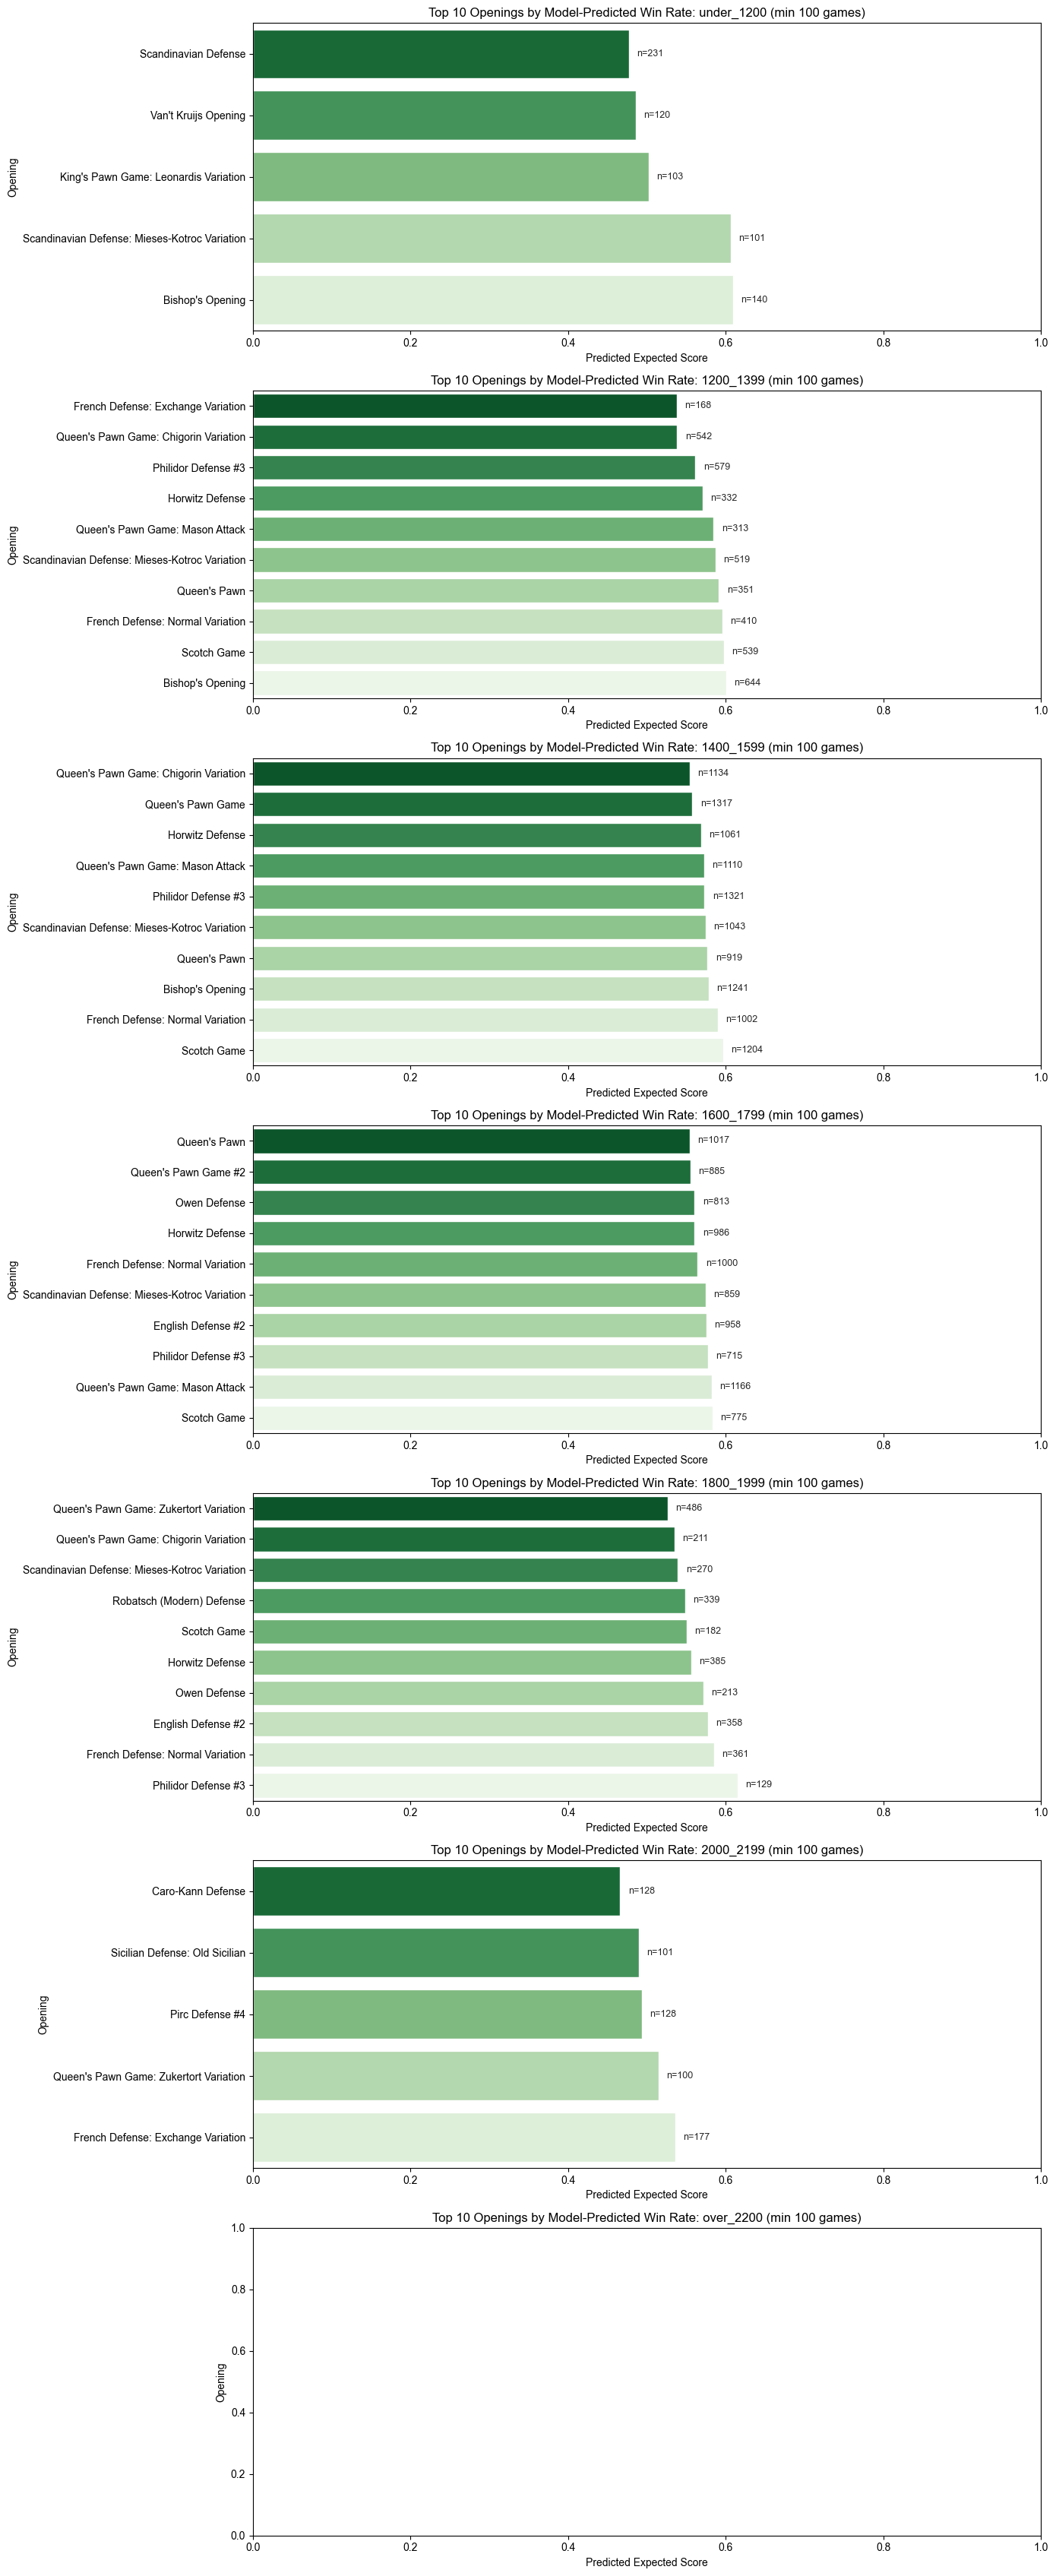

In [16]:
for event_name in EVENT_ORDER:
    top10_per_bracket = opening_analysis_by_event[event_name]["top10_per_bracket"]
    fig, axes = plt.subplots(len(bracket_order), 1, figsize=(14, 34))
    sns.set_style("whitegrid")

    for ax, bracket in zip(axes, bracket_order):
        plot_df = (
            top10_per_bracket[top10_per_bracket["Elo_Bracket"] == bracket]
            .sort_values("predicted_win_rate")
        )

        sns.barplot(
            data=plot_df,
            x="predicted_win_rate",
            y="Opening",
            ax=ax,
            palette="Greens_r"
        )

        ax.set_title(f"Top 10 Openings by Predicted Expected Score for {bracket} in {event_name}")
        ax.set_xlabel("Predicted Expected Score")
        ax.set_ylabel("Opening")
        ax.set_xlim(0, 1)

        for i, (_, row) in enumerate(plot_df.iterrows()):
            ax.text(row["predicted_win_rate"] + 0.01, i, f'n={row["games"]}', va="center", fontsize=9)

    plt.tight_layout()
    plt.show()


### Best Openings by Elo Bracket
The model was used to estimate the average predicted expected score for each opening within each Elo bracket. The top-ranked openings in each bracket represent openings that the model associates with stronger expected outcomes for players in that rating range.

These results should be interpreted as model-based trends rather than strict causal conclusions. A high-ranked opening may reflect both the opening itself and the player profiles that typically choose it.


In [48]:
combined_worst10_df = pd.concat(
    [opening_analysis_by_event[event_name]["worst10_per_bracket"] for event_name in EVENT_ORDER],
    ignore_index=True,
)
display(combined_worst10_df.sort_values(["event", "Elo_Bracket", "predicted_win_rate"], ascending=[True, True, True]))

,Elo_Bracket,Opening,games,predicted_win_rate,event
51,1200_1399,Van't Kruijs Opening,591,0.433810,rated_blitz
52,1200_1399,Sicilian Defense: McDonnell Attack,111,0.452594,rated_blitz
53,1200_1399,Sicilian Defense: Bowdler Attack,384,0.460666,rated_blitz
54,1200_1399,Sicilian Defense,383,0.469051,rated_blitz
55,1200_1399,Sicilian Defense: Old Sicilian,217,0.469183,rated_blitz
...,...,...,...,...,...
141,under_1200,Van't Kruijs Opening,117,0.442472,rated_classical
142,under_1200,King's Pawn Game: Leonardis Variation,116,0.446243,rated_classical
143,under_1200,Queen's Pawn Game: Chigorin Variation,101,0.503191,rated_classical
144,under_1200,Scandinavian Defense,192,0.536101,rated_classical


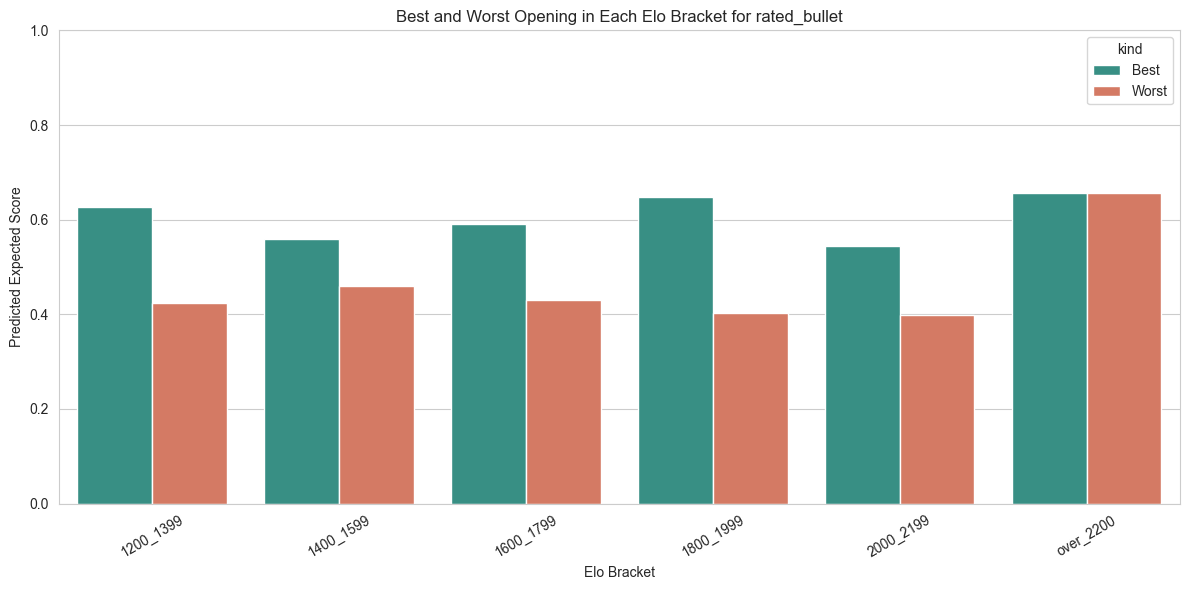

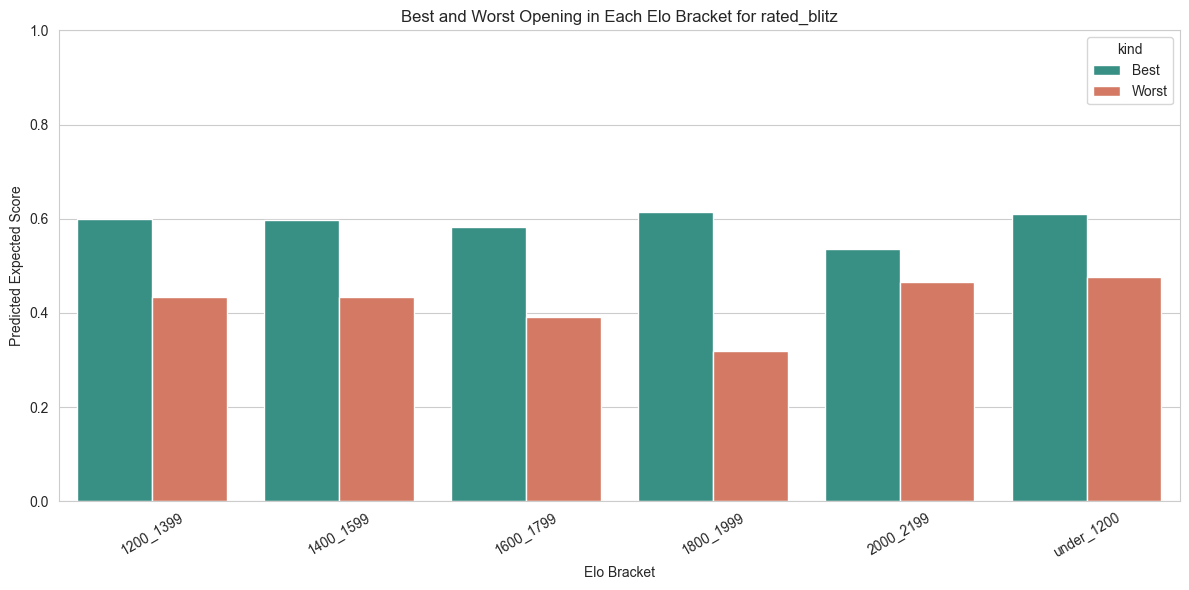

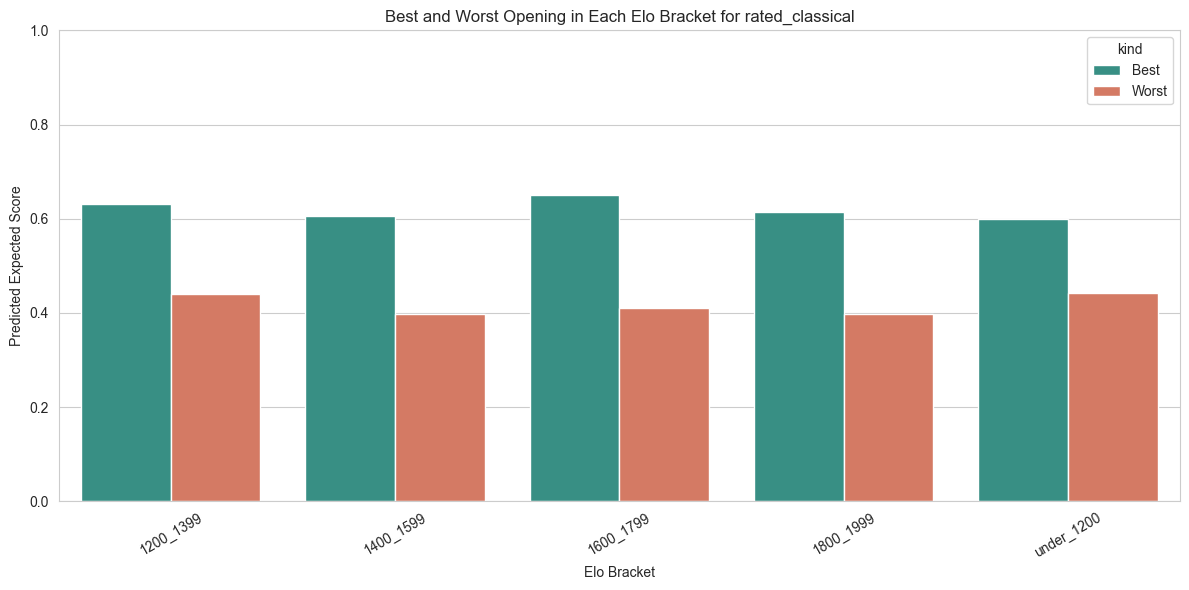

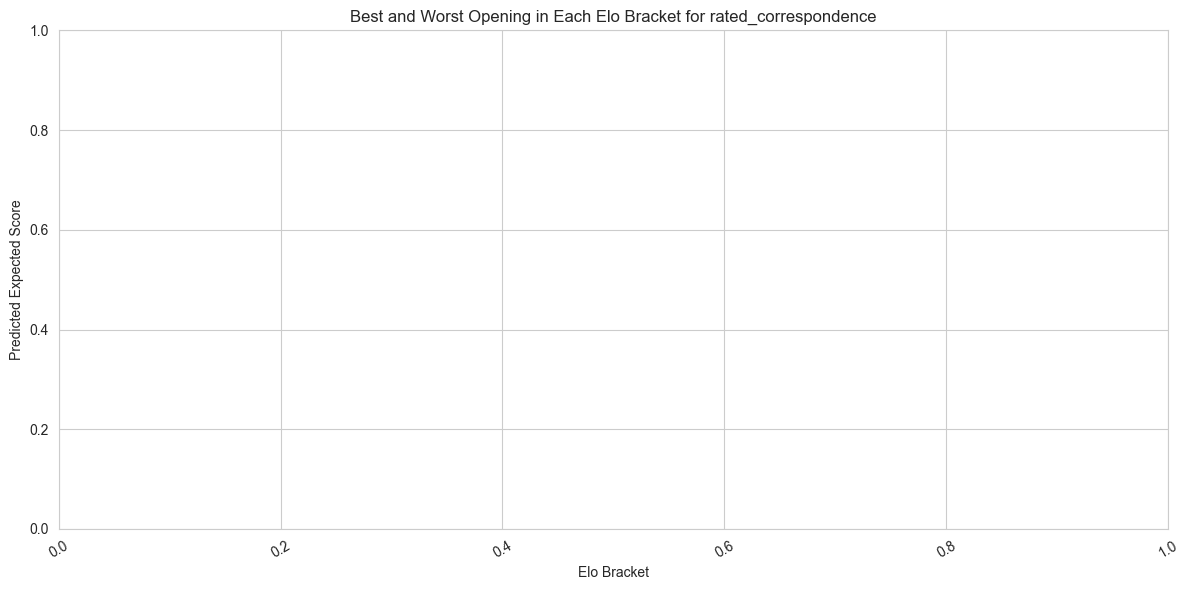

In [49]:
for event_name in EVENT_ORDER:
    top_openings = opening_analysis_by_event[event_name]["top_openings"]
    best1 = (
        top_openings.sort_values(
            ["Elo_Bracket", "predicted_win_rate", "games"],
            ascending=[True, False, False]
        )
        .groupby("Elo_Bracket", group_keys=False)
        .head(1)
        .assign(kind="Best")
    )

    worst1 = (
        top_openings.sort_values(
            ["Elo_Bracket", "predicted_win_rate", "games"],
            ascending=[True, True, False]
        )
        .groupby("Elo_Bracket", group_keys=False)
        .head(1)
        .assign(kind="Worst")
    )

    compare_df = pd.concat([best1, worst1], axis=0)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=compare_df,
        x="Elo_Bracket",
        y="predicted_win_rate",
        hue="kind",
        palette={"Best": "#2a9d8f", "Worst": "#e76f51"}
    )
    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.title(f"Best and Worst Opening in Each Elo Bracket for {event_name}")
    plt.ylabel("Predicted Expected Score")
    plt.xlabel("Elo Bracket")
    plt.tight_layout()
    plt.show()


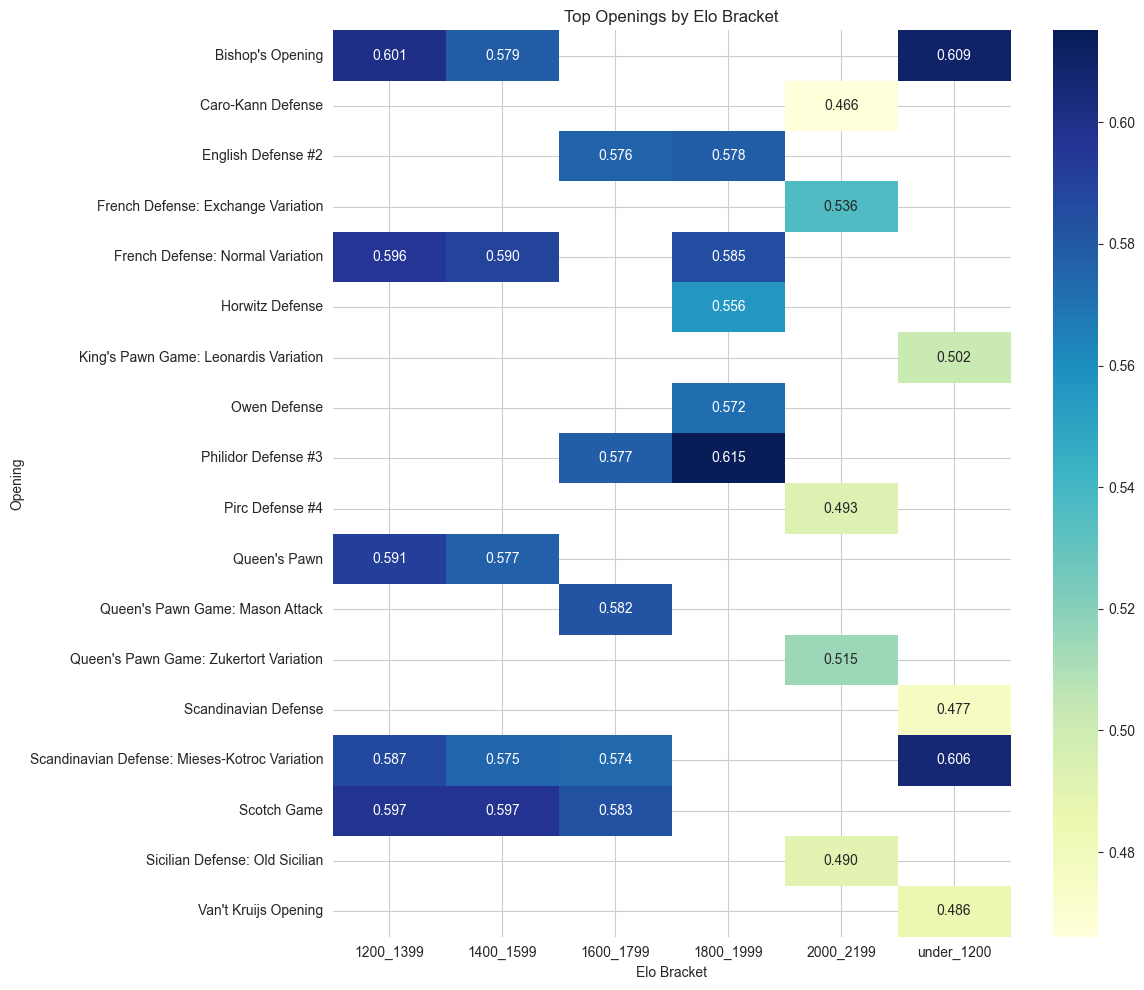

In [20]:
for event_name in EVENT_ORDER:
    top_openings = opening_analysis_by_event[event_name]["top_openings"]
    top_per_bracket = (
        top_openings.sort_values(
            ["Elo_Bracket", "predicted_win_rate", "games"],
            ascending=[True, False, False]
        )
        .groupby("Elo_Bracket", group_keys=False)
        .head(5)
    )

    heat_df = top_per_bracket.pivot_table(
        index="Opening",
        columns="Elo_Bracket",
        values="predicted_win_rate"
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title(f"Heatmap of Top Opening Scores by Elo Bracket for {event_name}")
    plt.xlabel("Elo Bracket")
    plt.ylabel("Opening")
    plt.tight_layout()
    plt.show()


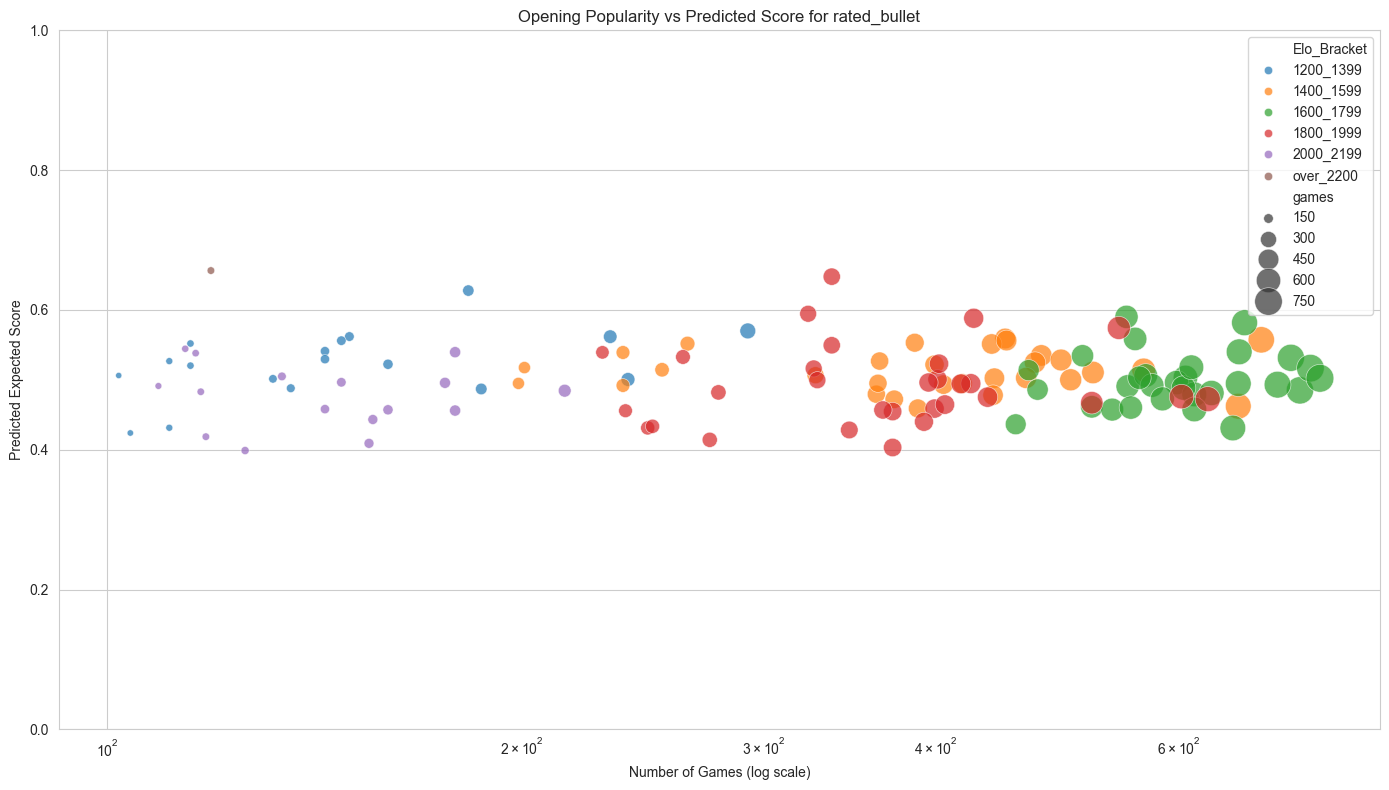

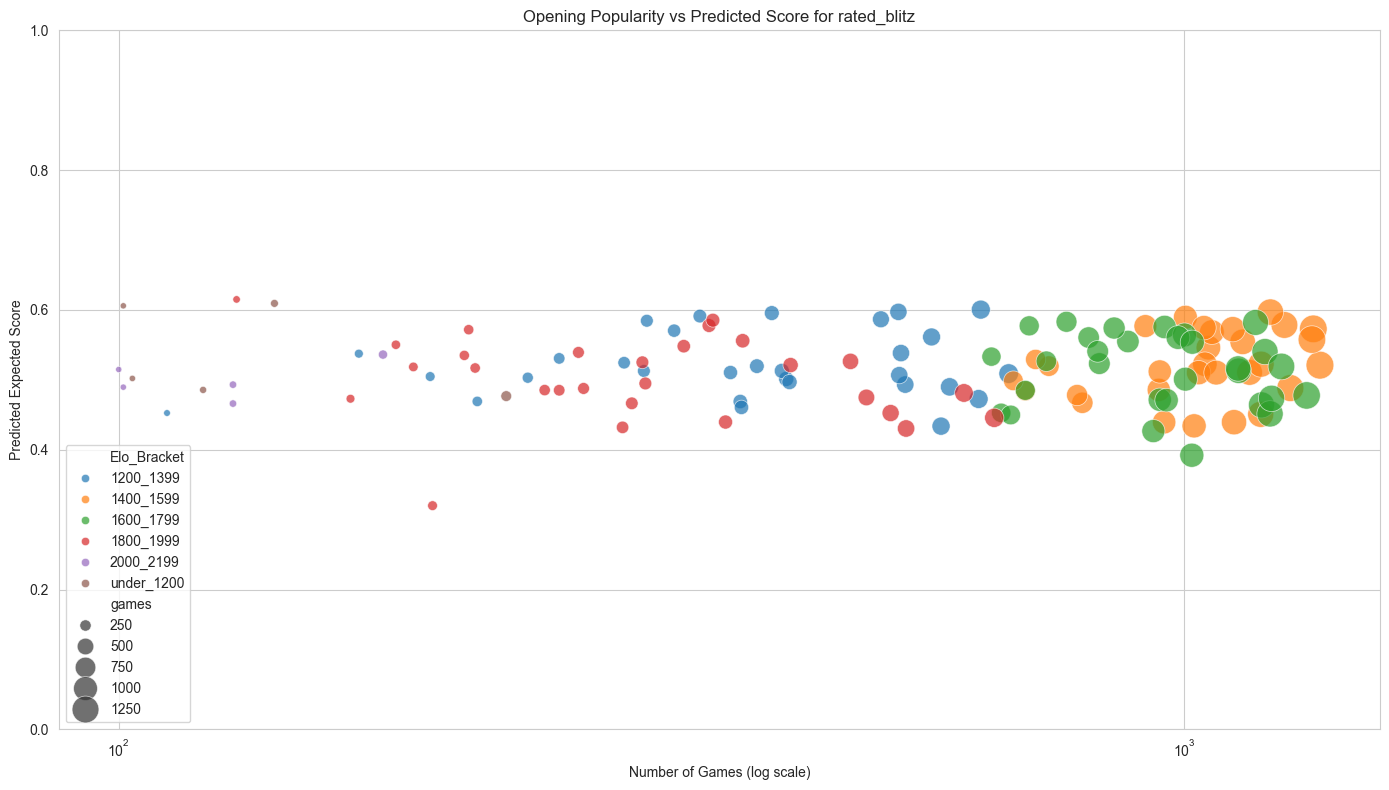

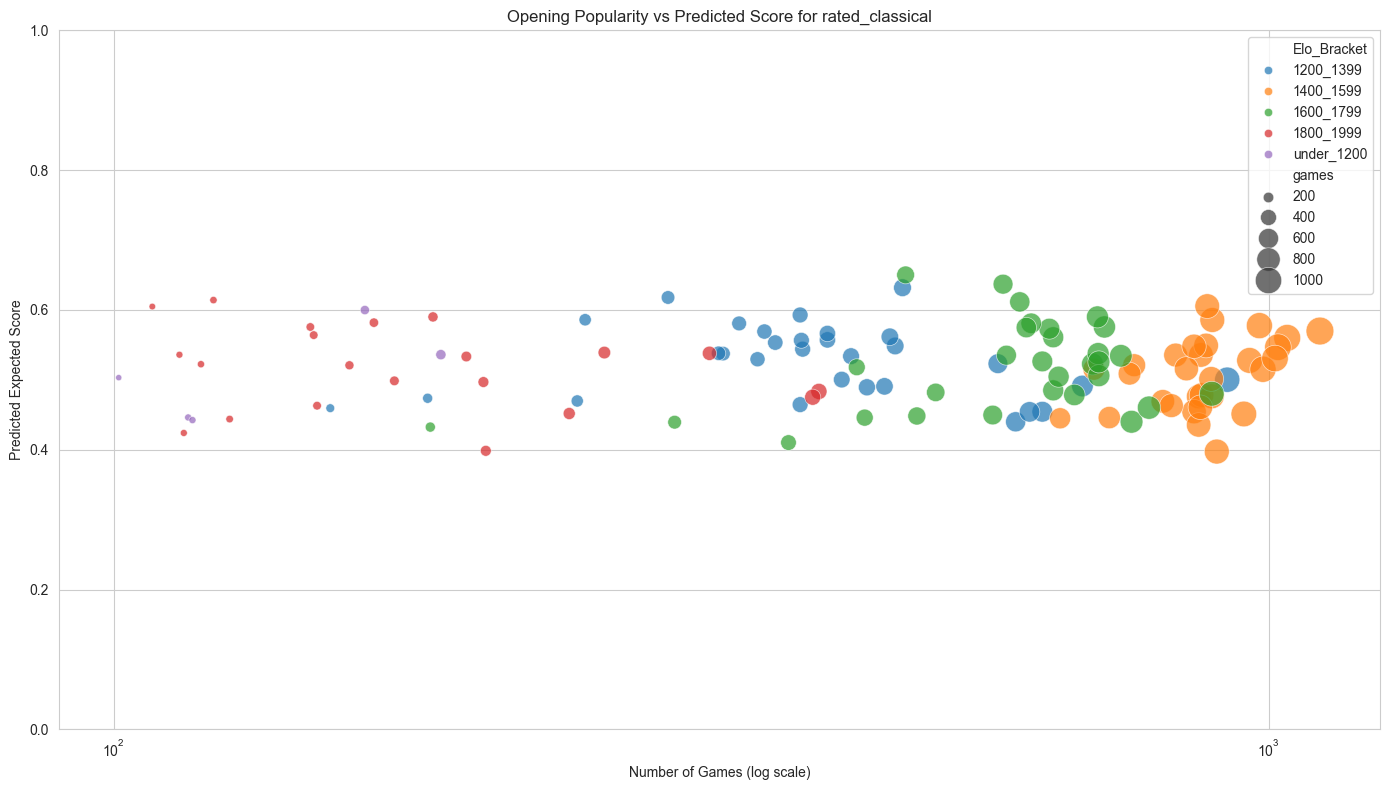

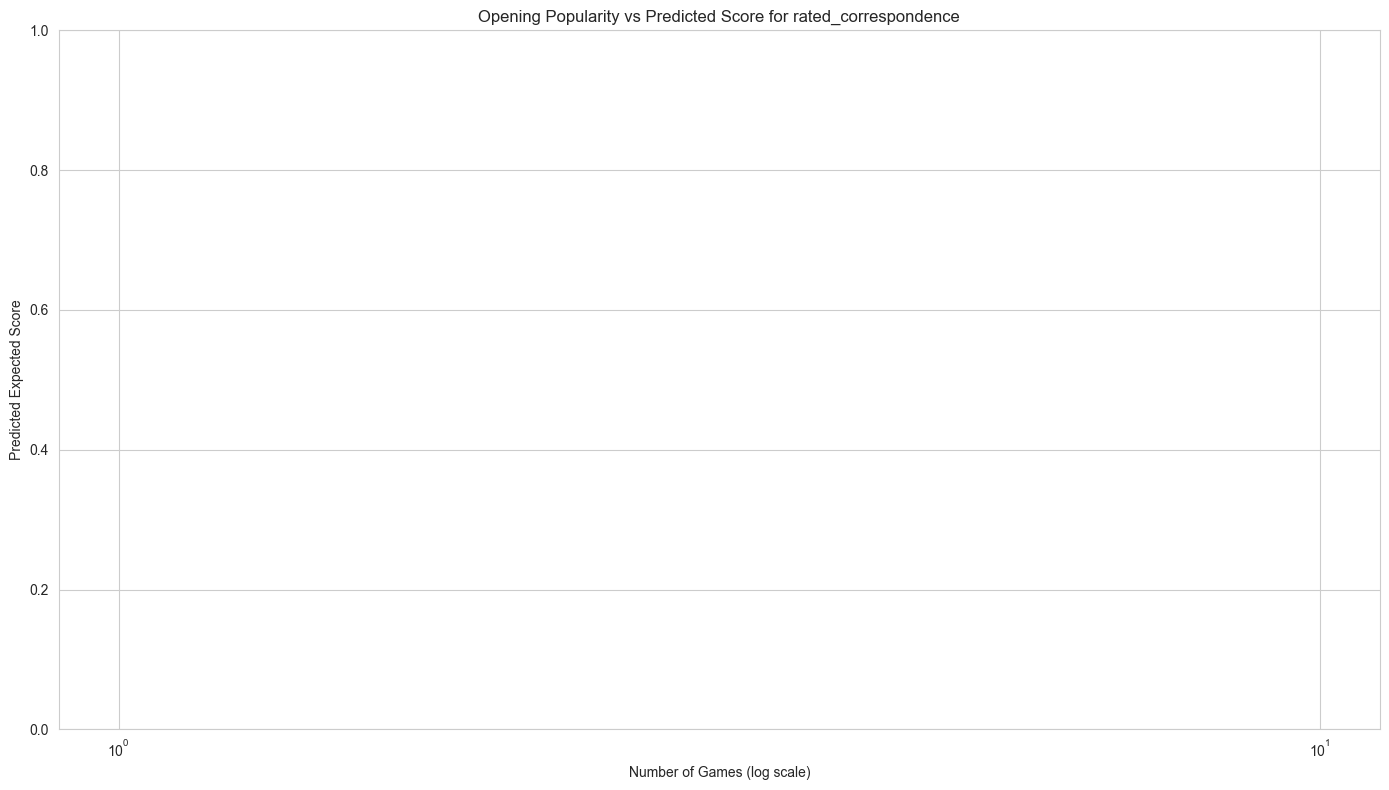

In [50]:
for event_name in EVENT_ORDER:
    plot_df = opening_analysis_by_event[event_name]["top_openings"].copy()

    plt.figure(figsize=(14, 8))
    sns.scatterplot(
        data=plot_df,
        x="games",
        y="predicted_win_rate",
        hue="Elo_Bracket",
        size="games",
        sizes=(20, 400),
        alpha=0.7
    )
    plt.xscale("log")
    plt.ylim(0, 1)
    plt.title(f"Opening Popularity vs Predicted Score for {event_name}")
    plt.xlabel("Number of Games (log scale)")
    plt.ylabel("Predicted Expected Score")
    plt.tight_layout()
    plt.show()


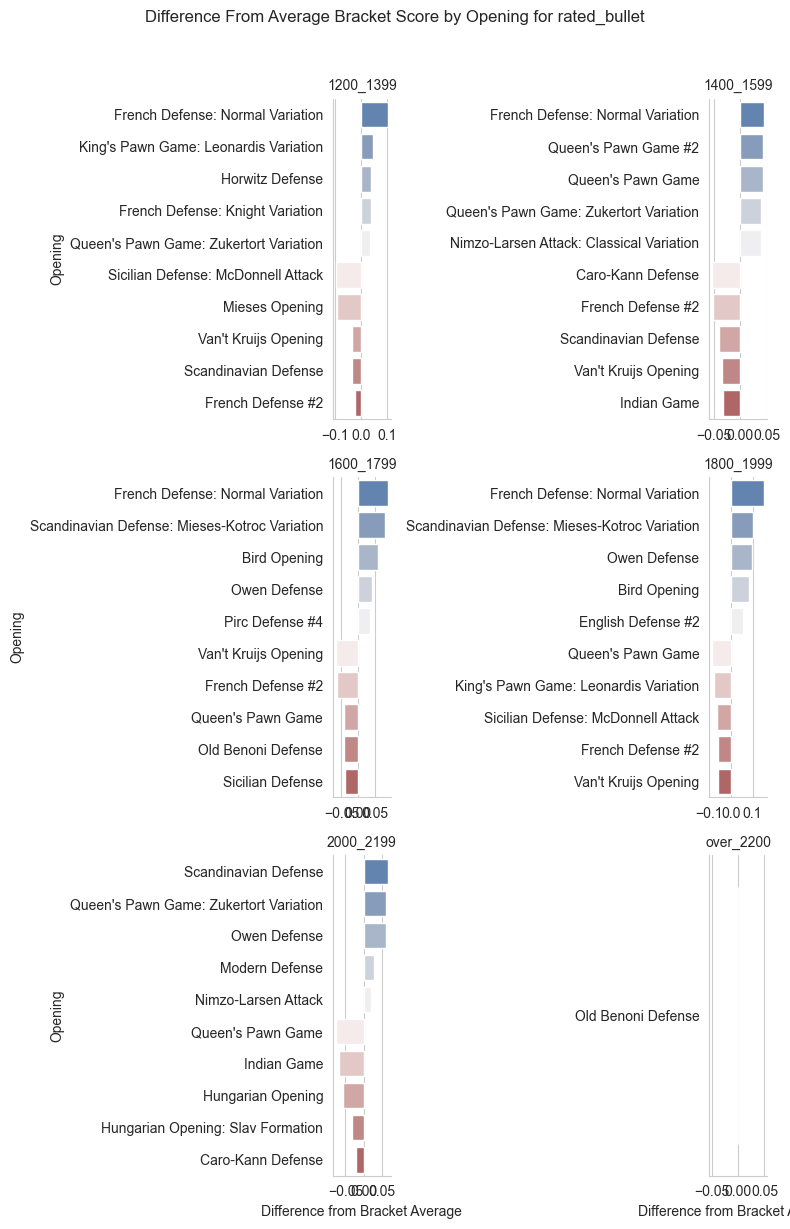

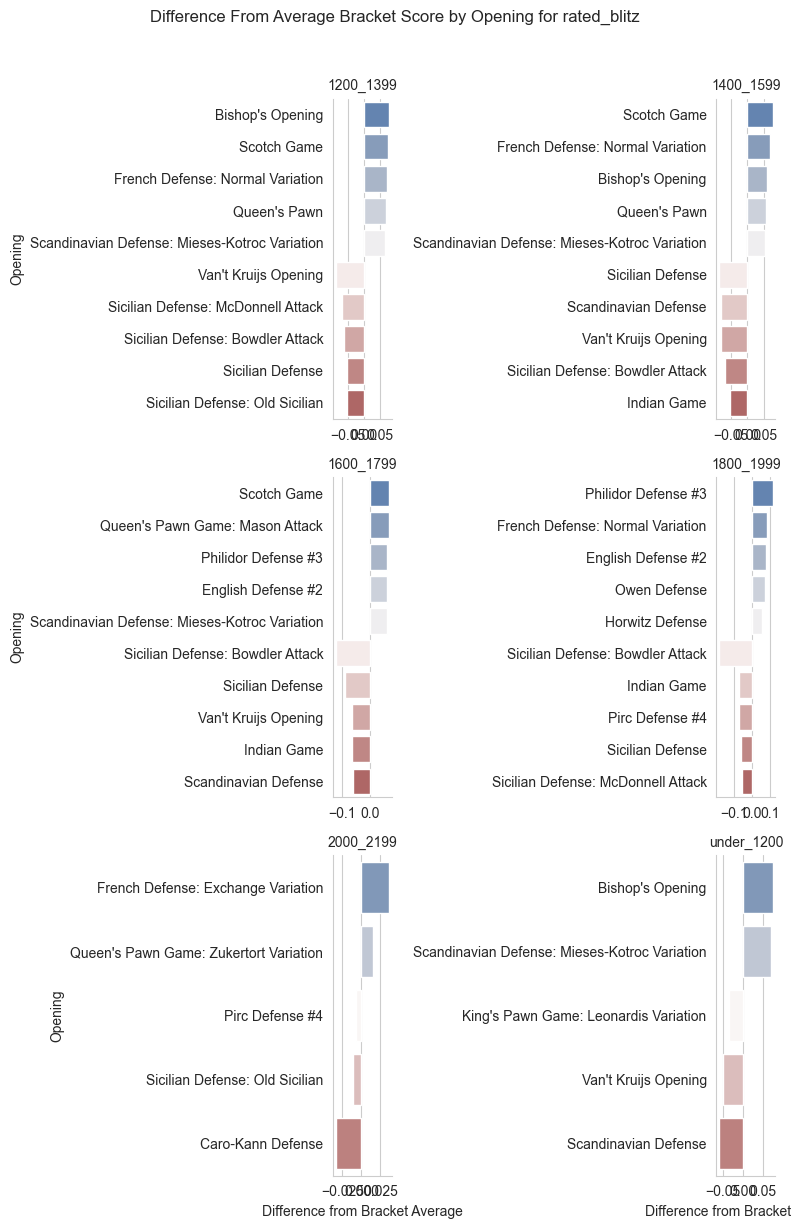

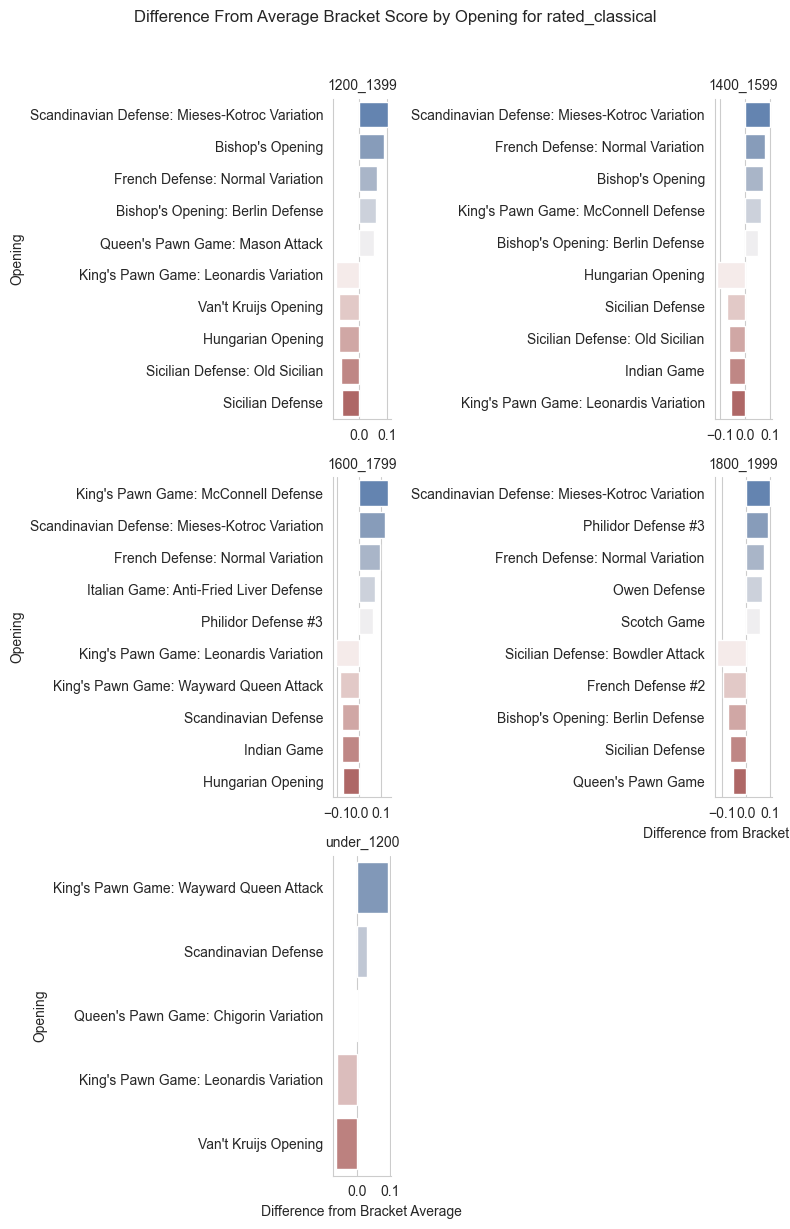

ValueError: Number of rows must be a positive integer, not 0

<Figure size 800x0 with 0 Axes>

In [51]:
for event_name in EVENT_ORDER:
    top_openings = opening_analysis_by_event[event_name]["top_openings"]
    bracket_avg = (
        top_openings.groupby("Elo_Bracket")["predicted_win_rate"]
        .mean()
        .rename("bracket_avg")
        .reset_index()
    )

    delta_df = top_openings.merge(bracket_avg, on="Elo_Bracket")
    delta_df["delta"] = delta_df["predicted_win_rate"] - delta_df["bracket_avg"]

    top_delta = (
        delta_df.sort_values(["Elo_Bracket", "delta"], ascending=[True, False])
        .groupby("Elo_Bracket", group_keys=False)
        .head(5)
    )

    bottom_delta = (
        delta_df.sort_values(["Elo_Bracket", "delta"], ascending=[True, True])
        .groupby("Elo_Bracket", group_keys=False)
        .head(5)
    )

    fun_df = pd.concat([top_delta, bottom_delta], axis=0)

    g = sns.FacetGrid(fun_df, col="Elo_Bracket", col_wrap=2, height=4, sharex=False, sharey=False)
    g.map_dataframe(
        sns.barplot,
        x="delta",
        y="Opening",
        palette="vlag"
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Difference from Bracket Average", "Opening")
    g.fig.suptitle(f"Difference From Average Bracket Score by Opening for {event_name}", y=1.02)
    plt.tight_layout()
    plt.show()

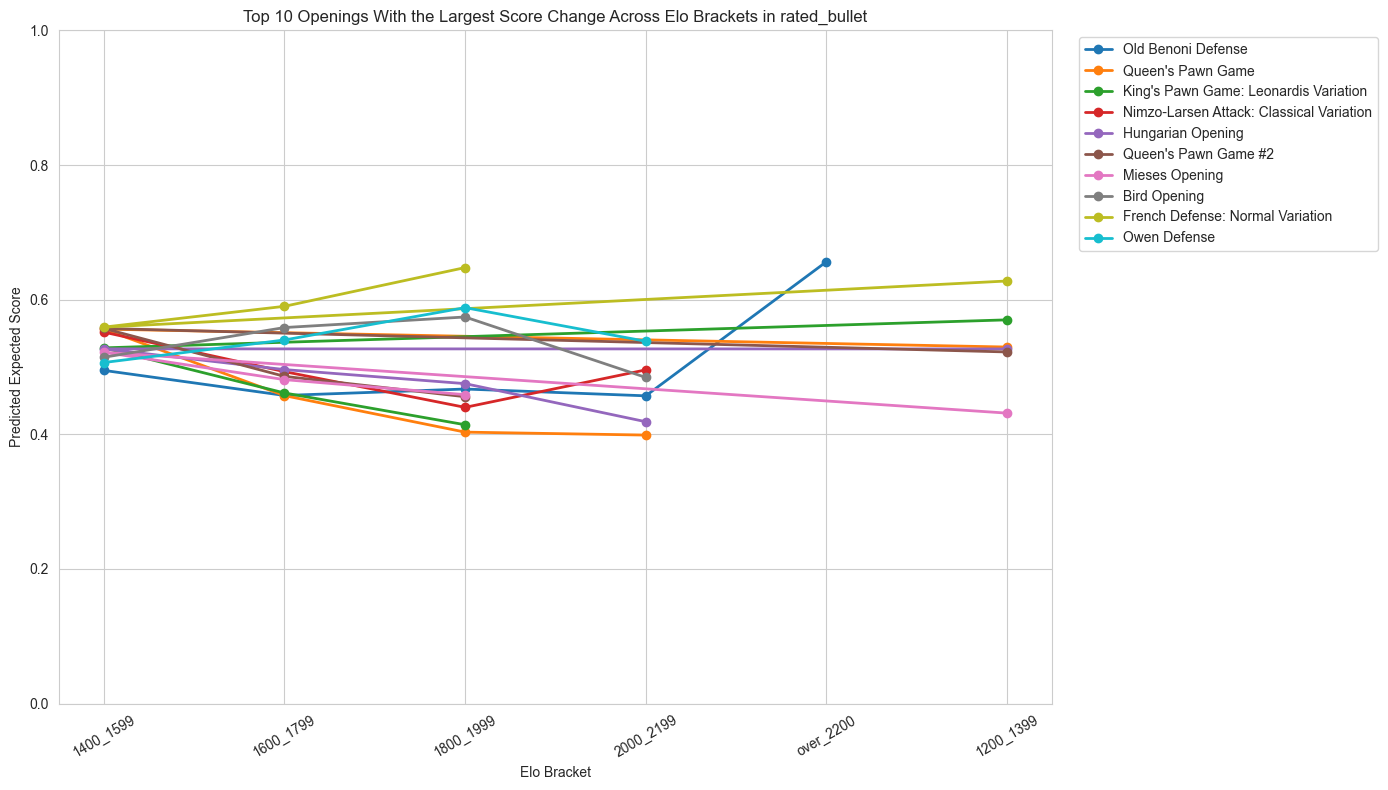

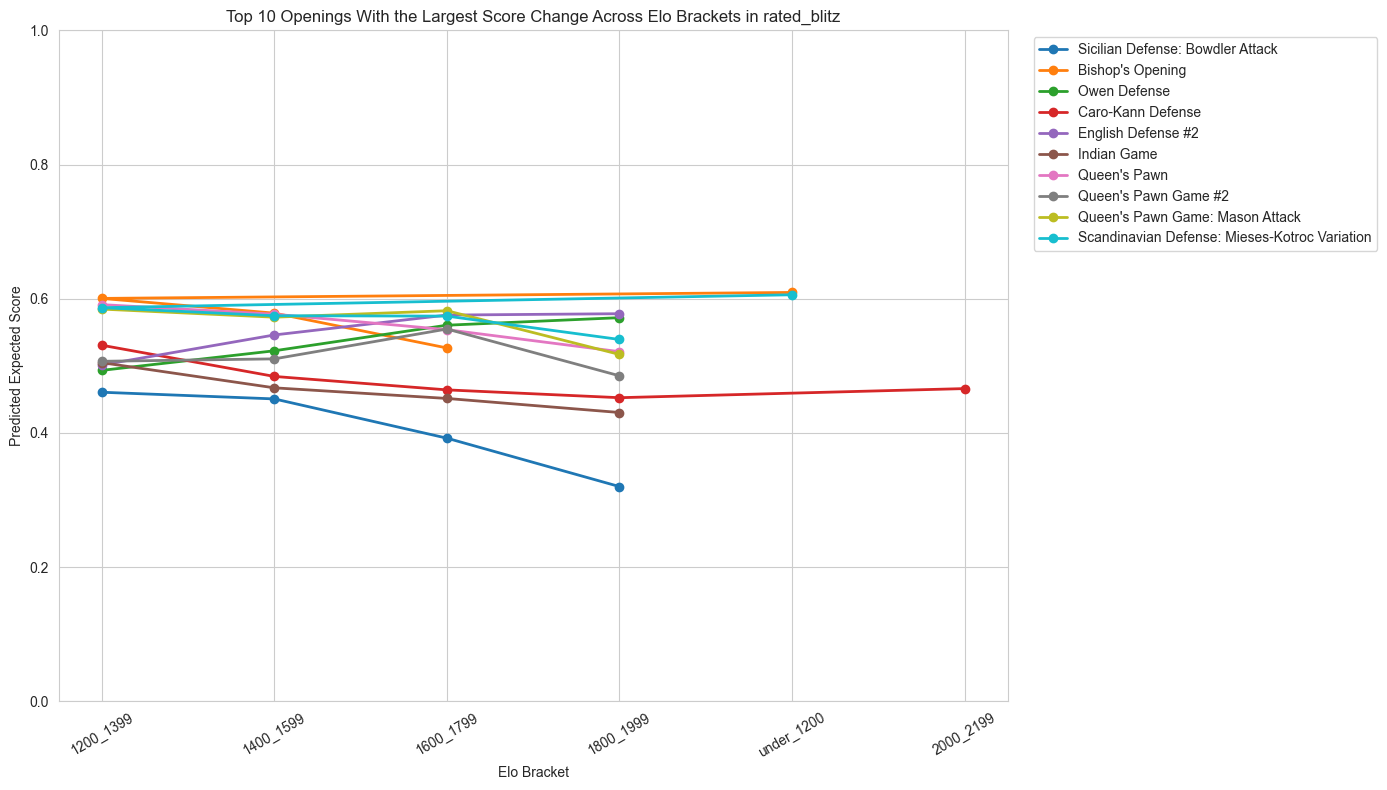

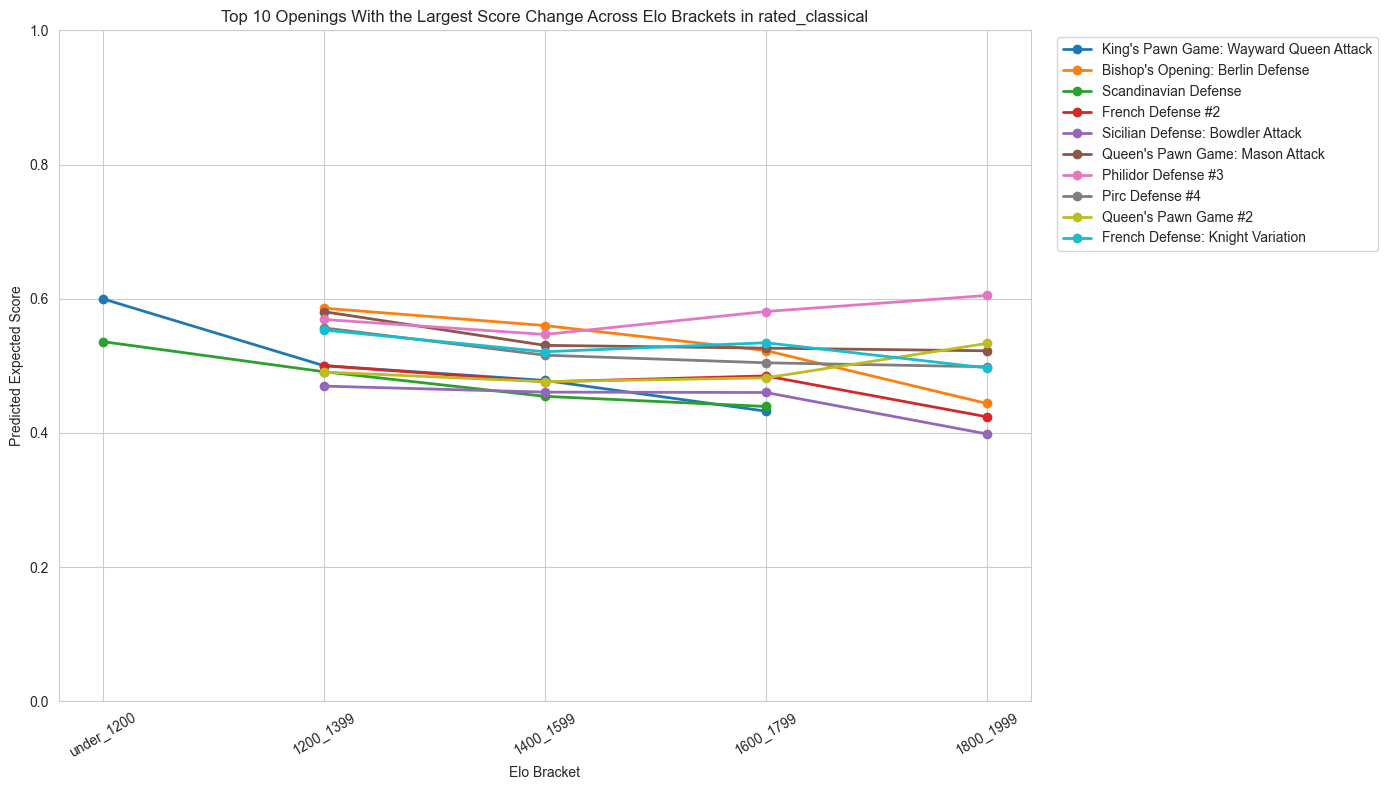

/var/folders/gp/sqskwmjx2zb7y096nd_t8_f80000gn/T/ipykernel_32924/3521424885.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")


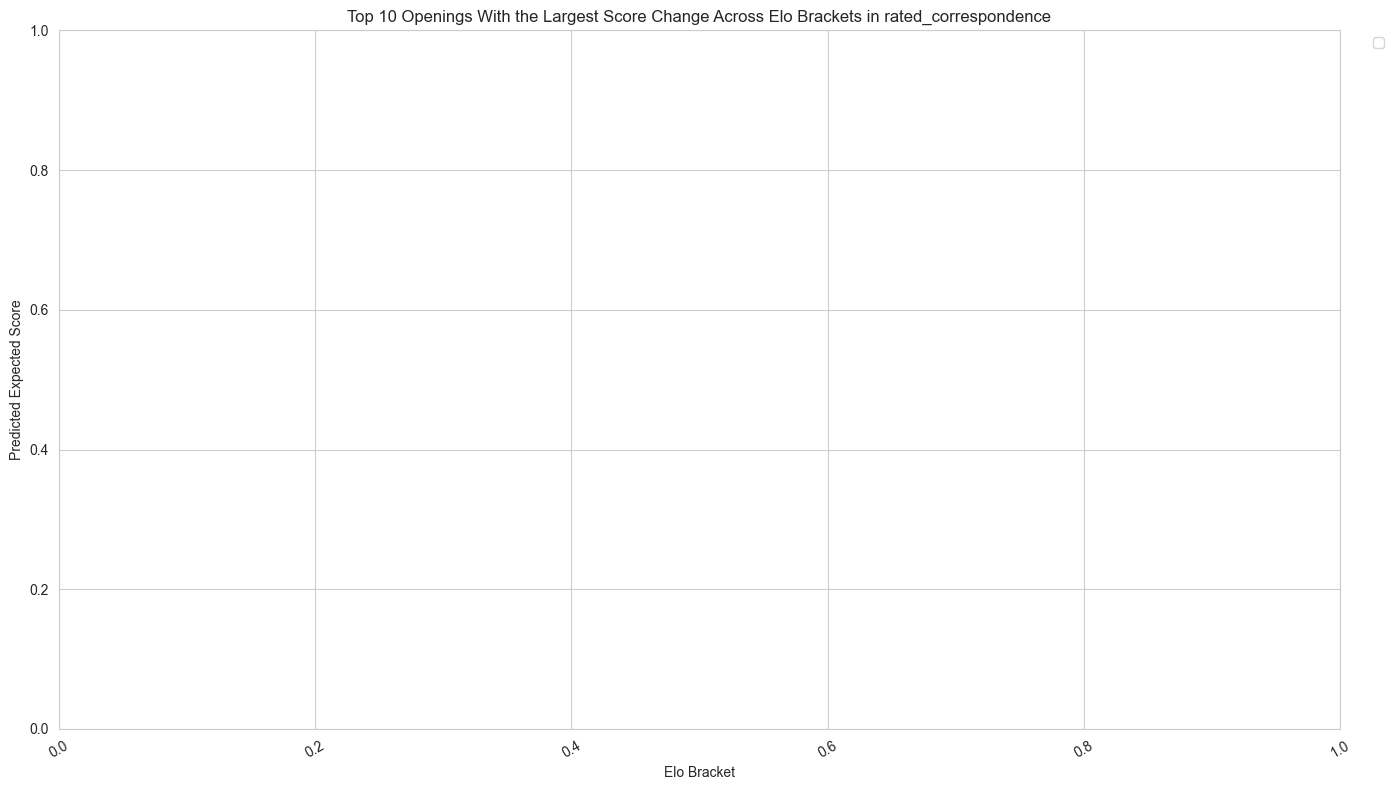

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MIN_GAMES_TOTAL = 500
MIN_BRACKETS_PRESENT = 4

for event_name in EVENT_ORDER:
    top_openings = opening_analysis_by_event[event_name]["top_openings"]
    variation_df = top_openings.copy()
    variation_df["Elo_Bracket"] = pd.Categorical(
        variation_df["Elo_Bracket"],
        categories=bracket_order,
        ordered=True
    )

    opening_variation = (
        variation_df.groupby("Opening")
        .agg(
            total_games=("games", "sum"),
            n_brackets=("Elo_Bracket", "nunique"),
            min_score=("predicted_win_rate", "min"),
            max_score=("predicted_win_rate", "max"),
            mean_score=("predicted_win_rate", "mean"),
            std_score=("predicted_win_rate", "std"),
        )
        .reset_index()
    )

    opening_variation["score_range"] = opening_variation["max_score"] - opening_variation["min_score"]

    selected = (
        opening_variation[
            (opening_variation["total_games"] >= MIN_GAMES_TOTAL) &
            (opening_variation["n_brackets"] >= MIN_BRACKETS_PRESENT)
        ]
        .sort_values(["score_range", "total_games"], ascending=[False, False])
        .head(10)["Opening"]
    )

    plot_df = variation_df[variation_df["Opening"].isin(selected)].copy()

    plt.figure(figsize=(14, 8))
    for opening in selected:
        sub = plot_df[plot_df["Opening"] == opening].sort_values("Elo_Bracket")
        plt.plot(
            sub["Elo_Bracket"],
            sub["predicted_win_rate"],
            marker="o",
            linewidth=2,
            label=opening
        )

    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.title(f"Top 10 Openings With the Largest Score Change Across Elo Brackets in {event_name}")
    plt.xlabel("Elo Bracket")
    plt.ylabel("Predicted Expected Score")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
